In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.12.0+cu126
CUDA Available: True
CUDA Version: 12.6
GPU Name: NVIDIA RTX 4000 Ada Generation


In [3]:
# ============================================================
# Step 1 — Environment, Imports, Reproducibility, and Runtime Setup
# Target Architecture: Mask2Former + Probabilistic Masked Attention (PMA)
# Target Dataset: Cityscapes
# Optimization Mode: ABLATION STUDY - NO BACKBONE FREEZING (AB1)
# ============================================================

import os
import cv2
import gc
import math
import glob
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Strict CUDA memory behavior to prevent fragmentation on 16GB/24GB VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Schedulers & Data Loading
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader

# VRAM Optimization Tools (AMP & Checkpointing)
from torch.amp import GradScaler, autocast
from torch.utils.checkpoint import checkpoint 

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from sklearn.metrics import confusion_matrix

from transformers import Mask2FormerConfig, Mask2FormerForUniversalSegmentation

# --------------------------------------------------
# Cleanup and warning control
# --------------------------------------------------
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

warnings.filterwarnings("ignore", category=UserWarning)

# --------------------------------------------------
# Reproducibility Setup
# --------------------------------------------------
SEED = 42

def set_seed(seed: int = 42, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=False)
print(f"Seed set to {SEED} (deterministic=False for stable/efficient training)")

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# --------------------------------------------------
# Matplotlib & Seaborn Styling Setup
# --------------------------------------------------
%matplotlib inline
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

# --------------------------------------------------
# Device & Engine Configuration
# --------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Toolchain Version: {torch.version.cuda}")
    print(f"Total Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

if torch.cuda.is_available():
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("TF32 matrix operations enabled successfully.")
    except Exception as e:
        print(f"TF32 configuration skipped: {e}")

# --------------------------------------------------
# AMP Setup
# --------------------------------------------------
USE_AMP = torch.cuda.is_available()
scaler = GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)
print(f"Mixed Precision Training Enabled: {USE_AMP}")

# --------------------------------------------------
# CENTRALIZED DIRECTORY & PATH MAPPING
# --------------------------------------------------
# 1. Dataset Roots (Using expanduser() to properly resolve '~' in Ubuntu)
IMG_ROOT = Path("~/miniconda3/envs/foggy/Dataset/leftImg8bit_trainvaltest/leftImg8bit").expanduser()
MASK_ROOT = Path("~/miniconda3/envs/foggy/Dataset/gtFine_trainvaltest/gtFine").expanduser()

# 2. Main Output Root for Ablation Study
OUTPUT_DIR = Path("~/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1").expanduser()

FINAL_SAVE_DIR = OUTPUT_DIR / "Results_Export"
QUAL_VIS_DIR = OUTPUT_DIR / "training_visuals"

# 3. Local Working Directories (Routed inside the AB1 folder)
CHECKPOINT_DIR = OUTPUT_DIR / "progressive_checkpoints"
PLOTS_DIR = OUTPUT_DIR / "training_plots"
LOGS_DIR = OUTPUT_DIR / "training_logs"
METRICS_DIR = OUTPUT_DIR / "training_metrics"

# Safely build all target directories
for d in [OUTPUT_DIR, CHECKPOINT_DIR, PLOTS_DIR, LOGS_DIR, METRICS_DIR, FINAL_SAVE_DIR, QUAL_VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Model Specifications
# --------------------------------------------------
MODEL_NAME = "facebook/mask2former-swin-small-cityscapes-semantic"
MODEL_ALIAS = "Mask2Former + PMA (NO BACKBONE FREEZING)"

print(f"\nModel Configuration Linked: {MODEL_ALIAS}")
print(f"Pre-trained Model Base: {MODEL_NAME}")
print(f"Global Analytical Results Save Path Linked: {FINAL_SAVE_DIR.resolve()}")
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR.resolve()}")

# --------------------------------------------------
# Runtime Performance Containers
# --------------------------------------------------
history = {
    "epoch": [],
    "phase": [],
    # Training Loop Loss Tracking
    "train_total_loss": [],
    "train_native_loss": [],
    "train_ce_loss": [],
    "train_lovasz_loss": [],
    "train_boundary_loss": [], 
    "train_miou": [],    
    "train_macc": [],    
    "train_aacc": [],    
    # Validation Evaluation Metrics
    "val_total_loss": [], # Critical for plotting validation loss
    "val_ce_loss": [],
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],
    # Optimizer State & Module Dynamics Records
    "backbone_lr": [],
    "head_lr": [],
    "pma_tau": [],  # Tracking our continuous masking temperature parameter
    "epoch_time_sec": []
}

best_record = {
    "epoch": -1,
    "best_epoch": -1,
    "best_miou": -1.0,
    "best_macc": -1.0,
    "best_aacc": -1.0,
    "best_path": str(CHECKPOINT_DIR / "best_miou_pma_checkpoint.pt")
}

print("Metrics tracking layers constructed. Global paths centralized. Step 1 initialization sequence completed.")

Seed set to 42 (deterministic=False for stable/efficient training)
Using Device: cuda
GPU Model: NVIDIA RTX 4000 Ada Generation
CUDA Toolchain Version: 12.6
Total Available GPU Memory: 19.67 GB
TF32 matrix operations enabled successfully.
Mixed Precision Training Enabled: True

Model Configuration Linked: Mask2Former + PMA (NO BACKBONE FREEZING)
Pre-trained Model Base: facebook/mask2former-swin-small-cityscapes-semantic
Global Analytical Results Save Path Linked: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1/Results_Export
Checkpoints will be saved to: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1/progressive_checkpoints
Metrics tracking layers constructed. Global paths centralized. Step 1 initialization sequence completed.


In [4]:
# ============================================================
# STEP 2: HYPERPARAMETERS, LABEL ENCODING, VISUALIZATION
# Target Architecture: Mask2Former + Probabilistic Masked Attention (PMA)
# Target Dataset: Cityscapes
# Optimization Mode: ABLATION STUDY - NO BACKBONE FREEZING (AB1)
# ============================================================

from pathlib import Path
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# Note: Paths (IMG_ROOT, MASK_ROOT, FINAL_SAVE_DIR, QUAL_VIS_DIR) 
# and DEVICE are globally inherited from Step 1.

print(f"Image root inherited: {IMG_ROOT}")
print(f"Mask root inherited : {MASK_ROOT}")
print(f"Visualizations target: {QUAL_VIS_DIR.resolve()}")
print(f"Final export target: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# CORE TASK SETTINGS (Cityscapes 19-Class Standard)
# ------------------------------------------------------------
CLASSES = 19
IGNORE_INDEX = 255
USE_LABEL_TRAINIDS = True

CLASS_NAMES = [
    "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
    "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
    "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
]

# Standard Cityscapes RGB Color Palette
CITYSCAPES_PALETTE = np.array([
    [128, 64, 128],   # Road
    [244, 35, 232],   # Sidewalk
    [70, 70, 70],     # Building
    [102, 102, 156],  # Wall
    [190, 153, 153],  # Fence
    [153, 153, 153],  # Pole
    [250, 170, 30],   # Traffic Light
    [220, 220, 0],    # Traffic Sign
    [107, 142, 35],   # Vegetation
    [152, 251, 152],  # Terrain
    [70, 130, 180],   # Sky
    [220, 20, 60],    # Person
    [255, 0, 0],      # Rider
    [0, 0, 142],      # Car
    [0, 0, 70],       # Truck
    [0, 60, 100],     # Bus
    [0, 80, 100],     # Train
    [0, 0, 230],      # Motorcycle
    [119, 11, 32]     # Bicycle
], dtype=np.uint8)

# ------------------------------------------------------------
# IMAGE GEOMETRY (Optimized for PMA + Multi-Scale Augmentation)
# ------------------------------------------------------------
# Training utilizes square crops for positional embedding stability
TRAIN_CROP_SIZE = (768, 768) 

# Validation uses sliding window on native aspect ratio
VAL_IMG_H = 512
VAL_IMG_W = 1024

# ------------------------------------------------------------
# BATCHING AND EPOCHS (Hardware Optimized for RTX A4000 16GB)
# ------------------------------------------------------------
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 4    # Effective batch size = 8
EPOCHS = 120
USE_EARLY_STOPPING = False  

# ------------------------------------------------------------
# PMA-MASK2FORMER OPTIMIZATION SCHEDULE (ABLATION MODIFIED)
# ------------------------------------------------------------
BASE_HEAD_LR = 5e-5       

# ABLATION EXPERIMENT: No Freezing. The entire network trains from Epoch 1.
FREEZE_BACKBONE_EPOCHS = 0 

# ABLATION EXPERIMENT: No differential LR. The backbone receives the same LR as the head.
BACKBONE_LR = 5e-5        

WARMUP_EPOCHS = 5           # Initial linear LR warmup

# APMA (Annealed Probabilistic Masked Attention) Parameters
APMA_INITIAL_TAU = 1.0    # Starts highly continuous (soft)
APMA_MIN_TAU = 0.05       # Hardens boundaries by final epochs

WEIGHT_DECAY = 0.01
GRAD_CLIP_NORM = 1.0      # Mandatory for continuous modules to prevent explosions
FREEZE_BATCHNORM_STATS = True  

print("\n--- ABLATION STUDY: NO BACKBONE FREEZING (AB1) ---")
print(f"Total Training Epochs  : {EPOCHS}")
print(f"Backbone Frozen Epochs : {FREEZE_BACKBONE_EPOCHS} Epochs (ABLATED)")
print(f"Linear Warmup Period   : {WARMUP_EPOCHS} Epochs")
print(f"Decoder Head LR        : {BASE_HEAD_LR}")
print(f"Swin Backbone LR       : {BACKBONE_LR} (ABLATED - Matched to Head LR)")
print(f"PMA Mask Temperature   : \u03c4 decays from {APMA_INITIAL_TAU} to {APMA_MIN_TAU}")

# ------------------------------------------------------------
# SCHEDULER / LOSS SETTINGS
# ------------------------------------------------------------
USE_FOCAL_LOSS = True   
FOCAL_GAMMA = 2.0
FOCAL_WEIGHT = 1.0

USE_LOVASZ = True
LOVASZ_WEIGHT = 0.5

USE_BOUNDARY_LOSS = True
BOUNDARY_LOSS_WEIGHT = 0.25

print("\n--- Loss Formulation ---")
print(f"Focal Loss Enabled    : {USE_FOCAL_LOSS} (Gamma={FOCAL_GAMMA}, Weight={FOCAL_WEIGHT})")
print(f"Lovasz Enabled        : {USE_LOVASZ} (Weight={LOVASZ_WEIGHT})")
print(f"Boundary Loss Enabled : {USE_BOUNDARY_LOSS} (Weight={BOUNDARY_LOSS_WEIGHT})")

# ------------------------------------------------------------
# VALIDATION / INFERENCE SETTINGS
# ------------------------------------------------------------
USE_SLIDING_WINDOW_VAL = True 
VAL_WINDOW_SIZE = (512, 1024)
VAL_WINDOW_STRIDE = (512, 512)   
USE_FLIP_TTA = True

# ------------------------------------------------------------
# 34 -> 19 LABEL MAPPING & ENCODING (Cityscapes Specific)
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    uniq = np.unique(mask)
    if uniq.max() <= 255 and np.all(np.isin(uniq, list(range(CLASSES)) + [IGNORE_INDEX])):
        return mask.astype(np.uint8)
    encoded = LABEL_LUT[mask.clip(0, 255)]
    return encoded.astype(np.uint8)

def decode_segmap(segmentation_map: np.ndarray) -> np.ndarray:
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    valid_mask = (segmentation_map >= 0) & (segmentation_map < CLASSES)
    for label, color in enumerate(CITYSCAPES_PALETTE):
        rgb[segmentation_map == label] = color
    rgb[~valid_mask] = np.array([0, 0, 0], dtype=np.uint8)
    return rgb

# ------------------------------------------------------------
# PUBLICATION-READY EVALUATION CURVES
# ------------------------------------------------------------
def plot_training_curves(history_dict, save_path):
    epochs = history_dict["epoch"]
    if len(epochs) == 0: return

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Total Loss Curve
    if len(history_dict.get("train_total_loss", [])) == len(epochs):
        axes[0].plot(epochs, history_dict["train_total_loss"], label='Train Total Loss', color='blue', linewidth=2)
    val_loss_arr = np.array(history_dict.get("val_total_loss", []))
    if len(val_loss_arr) == len(epochs) and not np.isnan(val_loss_arr).all() and not np.all(val_loss_arr == 0):
        axes[0].plot(epochs, val_loss_arr, label='Validation Loss', color='red', linewidth=2)
    axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    
    if len(epochs) >= WARMUP_EPOCHS:
        axes[0].axvline(x=WARMUP_EPOCHS, color='black', linestyle='--', label='Warmup Concluded')
    axes[0].legend(fontsize=12)

    # Plot 2: mIoU Curve
    if len(history_dict.get("train_miou", [])) == len(epochs):
        axes[1].plot(epochs, history_dict["train_miou"], label='Train mIoU', color='green', linewidth=2)
    if len(history_dict.get("val_miou", [])) == len(epochs):
        axes[1].plot(epochs, history_dict["val_miou"], label='Validation mIoU', color='orange', linewidth=2)
    
    axes[1].set_title('Training vs Validation mIoU', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('mIoU (%)', fontsize=12)
    
    if len(epochs) >= WARMUP_EPOCHS:
        axes[1].axvline(x=WARMUP_EPOCHS, color='black', linestyle='--', label='Warmup Concluded')
    axes[1].legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# QUALITATIVE VISUALIZATION
# ------------------------------------------------------------
def visualize_results(loader, model, epoch, save_path=QUAL_VIS_DIR, max_images=3):
    save_path = Path(save_path)
    save_path.mkdir(parents=True, exist_ok=True)
    model.eval()

    batch = next(iter(loader))
    images, mask_labels, class_labels = batch
    images = images.to(DEVICE)
    _, _, current_h, current_w = images.shape

    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=(torch.cuda.is_available() and images.is_cuda)):
            outputs = model(pixel_values=images)
            mask_preds = F.interpolate(outputs.masks_queries_logits, size=(current_h, current_w), mode="bilinear", align_corners=False)
            mask_cls = outputs.class_queries_logits.softmax(dim=-1)[..., :-1]
            semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds.sigmoid())
            preds = torch.argmax(semantic_logits, dim=1).cpu().numpy()

    images_np = images.detach().cpu().numpy()
    targets = np.full((len(images_np), current_h, current_w), IGNORE_INDEX, dtype=np.uint8)

    for batch_idx in range(len(class_labels)):
        for inst_idx, class_id in enumerate(class_labels[batch_idx]):
            cls_id = int(class_id.item())
            if cls_id != IGNORE_INDEX and 0 <= cls_id < CLASSES:
                instance_mask = mask_labels[batch_idx][inst_idx].cpu().numpy() == 1
                targets[batch_idx][instance_mask] = cls_id

    n = min(max_images, len(images_np))
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = np.transpose(images_np[i], (1, 2, 0))
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(decode_segmap(targets[i]))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(decode_segmap(preds[i]))
        axes[i, 2].set_title(f"PMA-Mask2Former Pred (Epoch {epoch})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    out_file = save_path / f"epoch_{epoch:03d}_comparison.png"
    plt.savefig(out_file, dpi=600, bbox_inches="tight")
    plt.close(fig)

def save_visuals_every_10_epochs(epoch, loader, model, save_path=QUAL_VIS_DIR, max_images=3):
    if epoch % 10 == 0:
        visualize_results(loader, model, epoch, save_path, max_images)

# ------------------------------------------------------------
# QUICK DATA DISCOVERY
# ------------------------------------------------------------
train_imgs = sorted(list(IMG_ROOT.rglob("*.png")))
train_masks = sorted(list(MASK_ROOT.rglob("*_labelIds.png")))

print(f"Discovered {len(train_imgs)} images and {len(train_masks)} masks.")
print("Step 2 fully configured for Ablation Study AB1 (No Freezing).")

Image root inherited: /home/ubuntu/miniconda3/envs/foggy/Dataset/leftImg8bit_trainvaltest/leftImg8bit
Mask root inherited : /home/ubuntu/miniconda3/envs/foggy/Dataset/gtFine_trainvaltest/gtFine
Visualizations target: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1/training_visuals
Final export target: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1/Results_Export

--- ABLATION STUDY: NO BACKBONE FREEZING (AB1) ---
Total Training Epochs  : 120
Backbone Frozen Epochs : 0 Epochs (ABLATED)
Linear Warmup Period   : 5 Epochs
Decoder Head LR        : 5e-05
Swin Backbone LR       : 5e-05 (ABLATED - Matched to Head LR)
PMA Mask Temperature   : τ decays from 1.0 to 0.05

--- Loss Formulation ---
Focal Loss Enabled    : True (Gamma=2.0, Weight=1.0)
Lovasz Enabled        : True (Weight=0.5)
Boundary Loss Enabled : True (Weight=0.25)
Discovered 5000 images and 5000 masks.
Step 2 fully configured for Ablation Study AB1 (No Freezing).


In [5]:
# ============================================================
# STEP 3: DATASET AND DATALOADERS
# Target Architecture: Mask2Former + Probabilistic Masked Attention (PMA)
# Target Dataset: Cityscapes
# Optimization Mode: ABLATION STUDY - NO BACKBONE FREEZING (AB1)
# ============================================================

import inspect
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import random

# ------------------------------------------------------------
# HARDCODED PATHS FOR STABILITY (CITYSCAPES)
# ------------------------------------------------------------
IMG_ROOT = Path("~/miniconda3/envs/foggy/Dataset/leftImg8bit_trainvaltest/leftImg8bit").expanduser()
MASK_ROOT = Path("~/miniconda3/envs/foggy/Dataset/gtFine_trainvaltest/gtFine").expanduser()

# ------------------------------------------------------------
# DATASET DISCOVERY FOR CITYSCAPES
# ------------------------------------------------------------
def get_cityscapes_pairs(split):
    img_split_dir = IMG_ROOT / split
    mask_split_dir = MASK_ROOT / split
    
    if not img_split_dir.exists() or not mask_split_dir.exists():
        raise FileNotFoundError(f"Cityscapes directories not found. Check: {img_split_dir} or {mask_split_dir}")
        
    # Cityscapes images end in _leftImg8bit.png
    all_imgs = sorted(list(img_split_dir.rglob("*_leftImg8bit.png")))
    
    valid_imgs = []
    valid_masks = []
    
    for img_path in all_imgs:
        # e.g., aachen_000000_000019_leftImg8bit.png -> aachen_000000_000019_gtFine_labelIds.png
        mask_name = img_path.name.replace("_leftImg8bit.png", "_gtFine_labelIds.png")
        city_name = img_path.parent.name
        mask_path = mask_split_dir / city_name / mask_name
        
        if mask_path.exists():
            valid_imgs.append(img_path)
            valid_masks.append(mask_path)
        else:
            print(f"Warning: No mask found for {img_path.name} at {mask_path}")
            
    return valid_imgs, valid_masks

# Safely extract paths
train_img_paths, train_mask_paths = get_cityscapes_pairs("train")
val_img_paths, val_mask_paths = get_cityscapes_pairs("val")

if len(train_img_paths) == 0 or len(val_img_paths) == 0:
    raise FileNotFoundError("Could not find valid Cityscapes image/mask pairs. Please check directory contents.")

print(f"\n--- Cityscapes Dataset Split (Ablation AB1) ---")
print(f"Training image/mask pairs   : {len(train_img_paths)}")
print(f"Validation image/mask pairs : {len(val_img_paths)}")

# ------------------------------------------------------------
# CITYSCAPES 34 -> 19 CLASS MAPPING
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

IGNORE_INDEX = 255
LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    """Fast mapping from 34 IDs to 19 Train IDs."""
    return LABEL_LUT[mask.clip(0, 255)].astype(np.uint8)

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
class CityscapesDataset(Dataset):
    def __init__(self, image_paths, mask_paths, split="train", transform=None, rare_class_ids=None, rare_retry_count=0):
        self.transform = transform
        self.split = split
        self.rare_class_ids = rare_class_ids if rare_class_ids is not None else []
        self.rare_retry_count = rare_retry_count
        self.images = image_paths
        self.masks = mask_paths

    def __len__(self):
        return len(self.images)

    def _contains_rare_class(self, mask):
        if len(self.rare_class_ids) == 0: return False
        unique_ids = np.unique(mask)
        return any(cls_id in unique_ids for cls_id in self.rare_class_ids)

    def __getitem__(self, idx):
        img_path = str(self.images[idx])
        mask_path = str(self.masks[idx])

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask_raw is None:
            raise ValueError(f"Failed to read mask: {mask_path}")
            
        mask = encode_mask(mask_raw)

        if self.transform is not None:
            if self.split == "train" and self.rare_retry_count > 0:
                selected_aug = None
                for _ in range(self.rare_retry_count):
                    augmented = self.transform(image=image, mask=mask)
                    aug_mask = augmented["mask"]
                    aug_mask_np = aug_mask.cpu().numpy() if torch.is_tensor(aug_mask) else aug_mask

                    if self._contains_rare_class(aug_mask_np):
                        selected_aug = augmented
                        break
                    selected_aug = augmented
                augmented = selected_aug
            else:
                augmented = self.transform(image=image, mask=mask)

            image = augmented["image"]
            mask = augmented["mask"]

        if not torch.is_tensor(image):
            image = torch.as_tensor(image).permute(2, 0, 1).float()
        if not torch.is_tensor(mask):
            mask = torch.as_tensor(mask, dtype=torch.long)
        else:
            mask = mask.long()

        # Build standard Mask2Former target format (K, H, W)
        unique_labels = torch.unique(mask)
        unique_labels = unique_labels[unique_labels != IGNORE_INDEX]

        if unique_labels.numel() == 0:
            class_labels = torch.empty((0,), dtype=torch.long)
            mask_labels = torch.empty((0, mask.shape[0], mask.shape[1]), dtype=torch.float32)
        else:
            class_labels = unique_labels.long()
            mask_labels = (mask.unsqueeze(0) == class_labels[:, None, None]).float()

        return image, mask_labels, class_labels

# ------------------------------------------------------------
# AUGMENTATION HELPERS & TRANSFORMS
# ------------------------------------------------------------
def pad_if_needed_tf(min_h, min_w, ignore_index=255):
    sig = inspect.signature(A.PadIfNeeded)
    kwargs = dict(min_height=min_h, min_width=min_w, border_mode=cv2.BORDER_CONSTANT, p=1.0)
    if "fill" in sig.parameters:
        kwargs.update(fill=0, fill_mask=ignore_index)
    else:
        kwargs.update(value=0, mask_value=ignore_index)
    return A.PadIfNeeded(**kwargs)

TRAIN_CROP_SIZE = globals().get("TRAIN_CROP_SIZE", (768, 768))
VAL_IMG_H = globals().get("VAL_IMG_H", 512)
VAL_IMG_W = globals().get("VAL_IMG_W", 1024)

# For Cityscapes (1024x2048), cropping to TRAIN_CROP_SIZE for training
train_transform = A.Compose([
    A.RandomScale(scale_limit=(-0.5, 1.0), interpolation=cv2.INTER_LINEAR, p=1.0), 
    pad_if_needed_tf(TRAIN_CROP_SIZE[0], TRAIN_CROP_SIZE[1], IGNORE_INDEX),
    A.RandomCrop(height=TRAIN_CROP_SIZE[0], width=TRAIN_CROP_SIZE[1], p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.3),
    A.GaussianBlur(blur_limit=(3, 3), p=0.1),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# Validation transform completely bypasses Cropping
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# ------------------------------------------------------------
# COLLATE FUNCTION
# ------------------------------------------------------------
def mask2former_collate_fn(batch):
    images = torch.stack([item[0] for item in batch], dim=0)
    mask_labels = [item[1] for item in batch]
    class_labels = [item[2] for item in batch]
    return images, mask_labels, class_labels

# ------------------------------------------------------------
# INITIALIZATION
# ------------------------------------------------------------
USE_RARE_CLASS_AWARE_SAMPLING = True
# Cityscapes Rare Classes: Wall, Fence, Pole, Traffic Light, Traffic Sign, Rider, Truck, Bus, Train, Motorcycle, Bicycle
RARE_CLASS_IDS = [3, 4, 5, 6, 7, 12, 14, 15, 16, 17, 18]  

rare_retry_count = 8 if USE_RARE_CLASS_AWARE_SAMPLING else 0
BATCH_SIZE = globals().get("BATCH_SIZE", 2)

train_dataset = CityscapesDataset(
    image_paths=train_img_paths, mask_paths=train_mask_paths, split="train",
    transform=train_transform, rare_class_ids=RARE_CLASS_IDS, rare_retry_count=rare_retry_count
)

val_dataset = CityscapesDataset(
    image_paths=val_img_paths, mask_paths=val_mask_paths, split="val",
    transform=val_transform, rare_class_ids=None, rare_retry_count=0
)

NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() is not None else 2)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

print(f"\n--- DataLoader Hardware Configuration ---")
print(f"Num workers         : {NUM_WORKERS}")
print(f"Pin memory          : {PIN_MEMORY}")
print(f"Rare retry count    : {rare_retry_count}")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    collate_fn=mask2former_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
    collate_fn=mask2former_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------
train_batch = next(iter(train_loader))
train_images, train_mask_labels, train_class_labels = train_batch

print("\n--- Train Batch Sanity Check ---")
print(f"Images shape              : {train_images.shape} (Targeting {TRAIN_CROP_SIZE[0]}x{TRAIN_CROP_SIZE[1]})")
print(f"Sample 0 num segments     : {train_mask_labels[0].shape[0]}")
print(f"Sample 0 mask tensor shape: {train_mask_labels[0].shape}")

val_batch = next(iter(val_loader))
val_images, _, _ = val_batch

assert train_images.shape[-2:] == TRAIN_CROP_SIZE, f"Expected train crop {TRAIN_CROP_SIZE}, got {train_images.shape[-2:]}"

print(f"Validation images shape   : {val_images.shape} (Native Cityscapes Resolution)")
print("\nStep 3 configured successfully for Cityscapes.")


--- Cityscapes Dataset Split (Ablation AB1) ---
Training image/mask pairs   : 2975
Validation image/mask pairs : 500

--- DataLoader Hardware Configuration ---
Num workers         : 4
Pin memory          : True
Rare retry count    : 8

--- Train Batch Sanity Check ---
Images shape              : torch.Size([2, 3, 768, 768]) (Targeting 768x768)
Sample 0 num segments     : 10
Sample 0 mask tensor shape: torch.Size([10, 768, 768])
Validation images shape   : torch.Size([1, 3, 1024, 2048]) (Native Cityscapes Resolution)

Step 3 configured successfully for Cityscapes.


In [6]:
# ============================================================
# STEP 4: MODEL, PMA INJECTION, LOSS, MULTI-RATE SCHEDULER
# Target Architecture: Swin-Small + Mask2Former + PMA
# Target Dataset: Cityscapes
# Optimization Mode: ABLATION STUDY - NO BACKBONE FREEZING (AB1)
# ============================================================

import os
import math
import types
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from transformers import Mask2FormerForUniversalSegmentation

# ------------------------------------------------------------
# SAFETY CHECKS & GLOBALS INHERITANCE
# ------------------------------------------------------------
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

# FORCED CITYSCAPES OVERRIDE: 19 Classes
CLASSES = 19
globals()['CLASSES'] = 19

IGNORE_INDEX = 255
globals()['IGNORE_INDEX'] = 255

EPOCHS = globals().get("EPOCHS", 120)

# ABLATION OVERRIDE: Backbone starts training at Epoch 1
FREEZE_BACKBONE_EPOCHS = 0 

APMA_INITIAL_TAU = globals().get("APMA_INITIAL_TAU", 1.0)
APMA_MIN_TAU = globals().get("APMA_MIN_TAU", 0.05)
FOCAL_WEIGHT = globals().get("FOCAL_WEIGHT", 1.0)
BOUNDARY_LOSS_WEIGHT = globals().get("BOUNDARY_LOSS_WEIGHT", 0.25)

# ABLATION OVERRIDE: Matched learning rates for full network training
BASE_HEAD_LR = 5e-5
BACKBONE_LR = 5e-5

WEIGHT_DECAY = globals().get("WEIGHT_DECAY", 0.01)
GRAD_ACCUM_STEPS = globals().get("GRAD_ACCUM_STEPS", 4)
WARMUP_EPOCHS = globals().get("WARMUP_EPOCHS", 5)

# ------------------------------------------------------------
# LOAD PRETRAINED BASE MODEL (Swin-Small + Mask2Former)
# ------------------------------------------------------------
MODEL_NAME = "facebook/mask2former-swin-small-cityscapes-semantic"
model = Mask2FormerForUniversalSegmentation.from_pretrained(
    MODEL_NAME, 
    ignore_mismatched_sizes=True, 
    num_labels=CLASSES
).to(DEVICE)

print(f"Loaded Base Model: {MODEL_NAME}")

# ------------------------------------------------------------
# NOVEL ARCHITECTURAL INJECTION: PROBABILISTIC MASKED ATTENTION (PMA)
# ------------------------------------------------------------
class PMAManager:
    """Manages the continuous temperature relaxation for Mask2Former Attention."""
    def __init__(self, initial_tau=1.0, min_tau=0.05, total_epochs=120):
        self.tau = initial_tau
        self.min_tau = min_tau
        self.decay_rate = (min_tau / initial_tau) ** (1.0 / total_epochs)

    def step_epoch(self):
        self.tau = max(self.min_tau, self.tau * self.decay_rate)
        
    def apply_pma(self, mask_logits):
        if mask_logits is None or not torch.is_tensor(mask_logits):
            return mask_logits
            
        scaled_logits = mask_logits / self.tau
        probs = torch.sigmoid(scaled_logits)
        bias = self.tau * torch.log(probs + 1e-6)
        return torch.clamp(bias, min=-50.0, max=0.0)

pma_manager = PMAManager(initial_tau=APMA_INITIAL_TAU, min_tau=APMA_MIN_TAU, total_epochs=EPOCHS)

def inject_pma_into_mask2former(model, manager):
    transformer_decoder = model.model.transformer_module.decoder

    for layer in transformer_decoder.layers:
        original_layer_forward = layer.forward
        
        def pma_layer_forward(self, *args, **kwargs):
            if 'attention_mask' in kwargs and kwargs['attention_mask'] is not None:
                kwargs['attention_mask'] = manager.apply_pma(kwargs['attention_mask'])
            return original_layer_forward(*args, **kwargs)

        layer.forward = types.MethodType(pma_layer_forward, layer)

    print("Probabilistic Masked Attention (PMA) successfully injected into Decoder Layers.")

inject_pma_into_mask2former(model, pma_manager)

if hasattr(model.model.pixel_level_module.encoder, "gradient_checkpointing"):
    model.model.pixel_level_module.encoder.gradient_checkpointing = True

# ------------------------------------------------------------
# HYBRID LOSS FORMULATION (Cityscapes 19-Class Weights)
# ------------------------------------------------------------
CITYSCAPES_WEIGHTS = torch.tensor([
    2.5, 4.0, 3.0, 7.5, 7.0, 6.0, 6.5, 5.5, 3.2, 4.5, 3.5, 5.0, 6.5, 3.0, 8.5, 8.5, 9.0, 7.5, 6.0
], dtype=torch.float32).to(DEVICE)

def compute_soft_boundary_map(semantic_logits: torch.Tensor) -> torch.Tensor:
    probs = F.softmax(semantic_logits.float(), dim=1)
    B, C, H, W = probs.shape
    boundary = torch.zeros((B, 1, H, W), device=probs.device, dtype=probs.dtype)
    dh = torch.abs(probs[:, :, :, 1:] - probs[:, :, :, :-1]).mean(dim=1, keepdim=True)
    boundary[:, :, :, 1:] += dh
    dv = torch.abs(probs[:, :, 1:, :] - probs[:, :, :-1, :]).mean(dim=1, keepdim=True)
    boundary[:, :, 1:, :] += dv
    return boundary.clamp(min=0.0, max=1.0)

def compute_boundary_loss(semantic_logits, dense_targets):
    with torch.no_grad():
        target_boundary = torch.zeros_like(dense_targets, dtype=torch.bool)
        valid = (dense_targets != IGNORE_INDEX)
        target_boundary[:, 1:] |= ((dense_targets[:, 1:] != dense_targets[:, :-1]) & valid[:, 1:] & valid[:, :-1])
        target_boundary[:, :, 1:] |= ((dense_targets[:, :, 1:] != dense_targets[:, :, :-1]) & valid[:, :, 1:] & valid[:, :, :-1])
        target_boundary = target_boundary.unsqueeze(1).float()
        
    pred_boundary = compute_soft_boundary_map(semantic_logits)
    return F.smooth_l1_loss(pred_boundary, target_boundary)

def compute_hybrid_loss(outputs, dense_targets):
    native_loss = outputs.loss if outputs.loss is not None else torch.tensor(0.0, device=DEVICE)
    
    H, W = dense_targets.shape[1], dense_targets.shape[2]
    mask_preds_up = F.interpolate(outputs.masks_queries_logits, size=(H, W), mode="bilinear", align_corners=False)
    mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
    
    semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())
    
    # Using Cityscapes specific focal weights
    ce_loss = F.cross_entropy(semantic_logits, dense_targets, weight=CITYSCAPES_WEIGHTS, ignore_index=IGNORE_INDEX)
    boundary_loss = compute_boundary_loss(semantic_logits, dense_targets)
    
    total_loss = native_loss + (FOCAL_WEIGHT * ce_loss) + (BOUNDARY_LOSS_WEIGHT * boundary_loss)
    return total_loss

# ------------------------------------------------------------
# SINGLE-RATE OPTIMIZER (Ablation AB1)
# ------------------------------------------------------------
backbone_params, head_params = [], []

for n, p in model.named_parameters():
    p.requires_grad = True
    if "base_model" in n and "pixel_level_module.encoder.encoder" in n:
        # ABLATION: No backbone freezing condition here.
        backbone_params.append(p)
    else:
        head_params.append(p)

param_groups = [{"params": head_params, "lr": BASE_HEAD_LR}]
if len(backbone_params) > 0: 
    param_groups.append({"params": backbone_params, "lr": BACKBONE_LR})

optimizer = optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999), eps=1e-8)

def unfreeze_swin_backbone(model, optimizer):
    # Left intact as a safety stub, but will not be triggered in AB1
    pass

# ------------------------------------------------------------
# SCHEDULER
# ------------------------------------------------------------
try:
    steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)  
except NameError:
    steps_per_epoch = max(1, 367 // (globals().get("BATCH_SIZE", 2) * GRAD_ACCUM_STEPS))

total_steps = steps_per_epoch * EPOCHS
warmup_steps = steps_per_epoch * WARMUP_EPOCHS

warmup_scheduler = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=(total_steps - warmup_steps), eta_min=1e-7)
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_steps])

print("Optimization pipeline ready. Single-rate scheduling dynamically initialized for AB1 (Cityscapes 19-Classes forced).")

Loading weights:   0%|          | 0/758 [00:00<?, ?it/s]

[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-small-cityscapes-semantic
Key                                                                                                                      | Status     | 
-------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the c

Loaded Base Model: facebook/mask2former-swin-small-cityscapes-semantic
Probabilistic Masked Attention (PMA) successfully injected into Decoder Layers.
Optimization pipeline ready. Single-rate scheduling dynamically initialized for AB1 (Cityscapes 19-Classes forced).


In [7]:
# ============================================================
# STEP 5: TRAINING LOOP (FAST ABLATION MODE)
# Target Architecture: Swin-Small + Mask2Former + PMA
# Target Dataset: Cityscapes
# Optimization Mode: ABLATION STUDY - NO BACKBONE FREEZING (AB1)
# ============================================================

import os
import gc
import math
import time
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from tqdm import tqdm

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
USE_AMP = torch.cuda.is_available()
AMP_DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

CLASSES = globals().get("CLASSES", 19) # Cityscapes
IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)
EPOCHS = globals().get("EPOCHS", 120)
GRAD_CLIP_NORM = 1.0
MIN_DELTA_MIOU = 0.001

# --- UNIFIED EXPORT DIRECTORIES (Ablation Routes) ---
OUTPUT_DIR = Path("~/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1").expanduser()
CHECKPOINT_DIR = OUTPUT_DIR / "progressive_checkpoints"
FINAL_SAVE_DIR = OUTPUT_DIR / "Results_Export"
QUAL_VIS_DIR = OUTPUT_DIR / "training_visuals"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
QUAL_VIS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

scaler = GradScaler("cuda", enabled=USE_AMP)

# Global variables recovery
best_record = globals().get("best_record", {
    "epoch": -1, "best_epoch": -1, "best_miou": -1.0, 
    "best_macc": -1.0, "best_aacc": -1.0, 
    "best_path": str(CHECKPOINT_DIR / "best_miou_pma_checkpoint.pt")
})

history = globals().get("history", {
    "epoch": [], "phase": [], "train_total_loss": [], 
    "train_miou": [], "val_total_loss": [], "val_miou": [], 
    "val_macc": [], "val_aacc": [], 
    "backbone_lr": [], "head_lr": [], "epoch_time_sec": [], "pma_tau": []
})

# ------------------------------------------------------------
# SEMANTIC TARGETS & METRICS HELPERS
# ------------------------------------------------------------
def get_semantic_logits(model_outputs, image_size):
    H, W = image_size
    mask_preds_up = F.interpolate(model_outputs.masks_queries_logits, size=(H, W), mode="bilinear", align_corners=False)
    mask_cls = F.softmax(model_outputs.class_queries_logits, dim=-1)[..., :-1]
    return torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())

def build_semantic_targets(mask_labels, class_labels, image_size, ignore_index=255):
    H, W = image_size
    batch_size = len(mask_labels)
    device = mask_labels[0].device if len(mask_labels) > 0 else DEVICE
    targets = torch.full((batch_size, H, W), fill_value=ignore_index, dtype=torch.long, device=device)
    for b in range(batch_size):
        if class_labels[b].numel() == 0: continue
        for inst_idx, cls_id in enumerate(class_labels[b]):
            cls_id = int(cls_id.item())
            if cls_id == ignore_index: continue
            targets[b][mask_labels[b][inst_idx] > 0.5] = cls_id
    return targets

def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    return {"mIoU": float(mIoU), "aAcc": float(aAcc), "mAcc": float(mAcc), "iou_per_class": iou_per_class, "acc_per_class": acc_per_class}

def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def get_lr_snapshot(optimizer):
    lrs = [pg["lr"] for pg in optimizer.param_groups]
    if len(lrs) == 1: return 0.0, lrs[0]
    return lrs[1], lrs[0]

# ------------------------------------------------------------
# CRASH RECOVERY PROTOCOL
# ------------------------------------------------------------
start_epoch = 1
global_update_step = 0
best_conf_matrix = None
best_metrics = None
training_start_time = time.time()
cumulative_training_time_sec = 0.0 
current_phase = "AB1: No Backbone Freezing"

latest_ckpt_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pt")

if os.path.exists(latest_ckpt_path):
    print(f"\n[*] CRASH RECOVERY TRIGGERED: Found checkpoint at {latest_ckpt_path}")
    try:
        checkpoint = torch.load(latest_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        global_update_step = checkpoint['global_update_step']
        best_record = checkpoint['best_record']
        history = checkpoint['history']
        cumulative_training_time_sec = checkpoint.get('cumulative_training_time_sec', 0.0)
        
        for _ in range(start_epoch - 1):
            pma_manager.step_epoch()
            
        expected_len = len(optimizer.param_groups)
        for attr_name in ['schedulers', '_schedulers']:
            if hasattr(scheduler, attr_name):
                for sub_sched in getattr(scheduler, attr_name):
                    if hasattr(sub_sched, 'base_lrs'):
                        while len(sub_sched.base_lrs) < expected_len:
                            sub_sched.base_lrs.append(globals().get("BACKBONE_LR", 5e-5))
        if hasattr(scheduler, 'base_lrs'):
            while len(scheduler.base_lrs) < expected_len:
                scheduler.base_lrs.append(globals().get("BACKBONE_LR", 5e-5))
        print(f"[*] Successfully restored state. Resuming training from Epoch {start_epoch}.")
    except Exception as e:
        print(f"[!] Warning: Failed to load checkpoint cleanly: {e}")
else:
    print("No previous checkpoint found. Starting fresh.")

GRAD_ACCUM_STEPS = globals().get("GRAD_ACCUM_STEPS", 4)
print(f"\n--- Launching PMA-Mask2Former FAST AB1 Pipeline (Cityscapes) ---")
print(f"Target Epochs: {EPOCHS} (Currently at {start_epoch})")

# ------------------------------------------------------------
# MAIN TRAINING LOOP
# ------------------------------------------------------------
for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start_time = time.time()
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_total_loss_sum = 0.0
    train_batches = 0
    train_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    train_pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)

    for step, (images, mask_labels, class_labels) in enumerate(train_pbar, start=1):
        images = images.to(DEVICE, non_blocking=True)
        target_list = []
        for i in range(len(class_labels)):
            if len(class_labels[i]) > 0:
                target_list.append({"masks": mask_labels[i].to(DEVICE, non_blocking=True), "labels": class_labels[i].to(DEVICE, non_blocking=True)})
            else:
                target_list.append({"masks": torch.empty((0, images.shape[2], images.shape[3]), device=DEVICE), "labels": torch.empty((0,), dtype=torch.long, device=DEVICE)})

        _, _, curr_h, curr_w = images.shape
        dense_targets = build_semantic_targets([t["masks"] for t in target_list], [t["labels"] for t in target_list], (curr_h, curr_w), IGNORE_INDEX)

        with autocast("cuda", enabled=(USE_AMP and images.is_cuda), dtype=AMP_DTYPE):
            outputs = model(pixel_values=images, mask_labels=[t["masks"] for t in target_list], class_labels=[t["labels"] for t in target_list])
            total_loss = compute_hybrid_loss(outputs, dense_targets)
            loss = total_loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        train_total_loss_sum += total_loss.detach().item()
        train_batches += 1

        with torch.no_grad():
            semantic_logits = get_semantic_logits(outputs, (curr_h, curr_w))
            preds_np = torch.argmax(semantic_logits, dim=1).detach().cpu().numpy().astype(np.int64)
            targets_np = dense_targets.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                train_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)

        if (step % GRAD_ACCUM_STEPS == 0) or (step == len(train_loader)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
            try:
                scheduler.step()
            except ValueError as e:
                if "zip" in str(e):
                    for param_group in optimizer.param_groups:
                        param_group['lr'] = 1e-7
                else:
                    raise e
                    
            global_update_step += 1

        lr_backbone, lr_head = get_lr_snapshot(optimizer)
        train_pbar.set_postfix(loss=f"{train_total_loss_sum / max(1, train_batches):.4f}", lr=f"{lr_head:.2e}")

    train_metrics = compute_metrics(train_conf_matrix)
    train_total_loss = train_total_loss_sum / max(1, train_batches)

    # ------------------------------------------------------------
    # VALIDATION LOOP (TTA DISABLED FOR SPEED)
    # ------------------------------------------------------------
    model.eval()
    val_loss_sum = 0.0
    val_batches = 0
    val_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    val_pbar = tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{EPOCHS} [Val (Fast)]", leave=False)

    with torch.no_grad():
        for images, mask_labels, class_labels in val_pbar:
            images = images.to(DEVICE, non_blocking=True)
            _, _, val_h, val_w = images.shape
            
            target_list = []
            for i in range(len(class_labels)):
                if len(class_labels[i]) > 0:
                    target_list.append({"masks": mask_labels[i].to(DEVICE, non_blocking=True), "labels": class_labels[i].to(DEVICE, non_blocking=True)})
                else:
                    target_list.append({"masks": torch.empty((0, val_h, val_w), device=DEVICE), "labels": torch.empty((0,), dtype=torch.long, device=DEVICE)})
            
            dense_targets = build_semantic_targets([t["masks"] for t in target_list], [t["labels"] for t in target_list], (val_h, val_w), IGNORE_INDEX)

            # Single standard forward pass for BOTH loss and metrics
            with autocast("cuda", enabled=(USE_AMP and images.is_cuda), dtype=AMP_DTYPE):
                outputs = model(pixel_values=images, mask_labels=[t["masks"] for t in target_list], class_labels=[t["labels"] for t in target_list])
                v_loss = compute_hybrid_loss(outputs, dense_targets)
                val_loss_sum += v_loss.detach().item()
                val_batches += 1

            # Get logits directly from the standard pass (No multi-scale flips)
            semantic_logits = get_semantic_logits(outputs, (val_h, val_w))

            preds_np = torch.argmax(semantic_logits, dim=1).detach().cpu().numpy().astype(np.int64)
            targets_np = dense_targets.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                val_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)
            val_pbar.set_postfix(mIoU=f"{compute_metrics(val_conf_matrix)['mIoU'] * 100:.2f}%", loss=f"{val_loss_sum/val_batches:.4f}")

    val_total_loss = val_loss_sum / max(1, val_batches)
    val_metrics = compute_metrics(val_conf_matrix)
    
    current_tau = pma_manager.tau
    pma_manager.step_epoch()

    epoch_time = time.time() - epoch_start_time
    cumulative_training_time_sec += epoch_time  
    lr_backbone, lr_head = get_lr_snapshot(optimizer)

    epochs_processed_this_run = (epoch - start_epoch + 1)
    avg_epoch_time = cumulative_training_time_sec / epochs_processed_this_run
    remaining_epochs = EPOCHS - epoch
    eta_seconds = remaining_epochs * avg_epoch_time
    eta_str = str(timedelta(seconds=int(eta_seconds)))

    history["epoch"].append(epoch)
    history["phase"].append(current_phase)
    history["train_total_loss"].append(train_total_loss)
    history["val_total_loss"].append(val_total_loss)
    history["train_miou"].append(train_metrics["mIoU"] * 100) 
    history["val_miou"].append(val_metrics["mIoU"] * 100) 
    history["val_macc"].append(val_metrics["mAcc"] * 100) 
    history["val_aacc"].append(val_metrics["aAcc"] * 100) 
    history["backbone_lr"].append(lr_backbone)
    history["head_lr"].append(lr_head)
    history["epoch_time_sec"].append(epoch_time)
    history["pma_tau"].append(current_tau)

    print(
        f"\nEpoch {epoch}/{EPOCHS} | Epoch Time: {epoch_time:.2f}s | ETA: {eta_str}\n"
        f"Train Loss: {train_total_loss:.4f} | Train mIoU: {train_metrics['mIoU']*100:.2f}%\n"
        f"Val Loss:   {val_total_loss:.4f} | Val mIoU:   {val_metrics['mIoU']*100:.2f}% | Val aAcc:   {val_metrics['aAcc']*100:.2f}%\n"
        f"LR Backbone: {lr_backbone:.2e} | APMA \u03c4: {current_tau:.4f}"
    )

    ckpt_dict = {
        "epoch": epoch, "global_update_step": global_update_step,
        "model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(), "best_record": best_record,
        "history": history, "cumulative_training_time_sec": cumulative_training_time_sec 
    }
    torch.save(ckpt_dict, latest_ckpt_path)

    if val_metrics["mIoU"] > (best_record["best_miou"] + MIN_DELTA_MIOU):
        best_record["best_epoch"] = epoch
        best_record["best_miou"] = val_metrics["mIoU"]
        best_record["best_macc"] = val_metrics["mAcc"]
        best_record["best_aacc"] = val_metrics["aAcc"]
        best_conf_matrix = val_conf_matrix.copy()
        best_metrics = val_metrics.copy()
        torch.save(ckpt_dict, os.path.join(CHECKPOINT_DIR, "best_miou_pma_checkpoint.pt"))
        print(f"[*] New Best Validation mIoU: {val_metrics['mIoU']*100:.2f}% saved securely to disk.")

final_total_time_str = str(timedelta(seconds=int(cumulative_training_time_sec)))
print(f"\n--- Training Complete ---")
print(f"Best Epoch: {best_record['best_epoch']} | Best mIoU: {best_record['best_miou'] * 100:.2f}%")
BEST_CONF_MATRIX = best_conf_matrix
BEST_METRICS = best_metrics


[*] CRASH RECOVERY TRIGGERED: Found checkpoint at /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1/progressive_checkpoints/latest_checkpoint.pt
[*] Successfully restored state. Resuming training from Epoch 86.

--- Launching PMA-Mask2Former FAST AB1 Pipeline (Cityscapes) ---
Target Epochs: 120 (Currently at 86)



Epoch 86/120 | Epoch Time: 836.00s | ETA: 27 days, 19:21:18
Train Loss: 11.4381 | Train mIoU: 87.44%
Val Loss:   17.9335 | Val mIoU:   81.39% | Val aAcc:   96.59%
LR Backbone: 0.00e+00 | APMA τ: 0.1198



Epoch 87/120 | Epoch Time: 828.44s | ETA: 13 days, 15:39:38
Train Loss: 11.2198 | Train mIoU: 87.85%
Val Loss:   18.2033 | Val mIoU:   80.75% | Val aAcc:   96.49%
LR Backbone: 0.00e+00 | APMA τ: 0.1168



Epoch 88/120 | Epoch Time: 829.43s | ETA: 8 days, 22:16:42
Train Loss: 11.1482 | Train mIoU: 87.91%
Val Loss:   18.5047 | Val mIoU:   80.69% | Val aAcc:   96.53%
LR Backbone: 0.00e+00 | APMA τ: 0.1140



Epoch 89/120 | Epoch Time: 829.22s | ETA: 6 days, 13:28:18
Train Loss: 11.2242 | Train mIoU: 88.12%
Val Loss:   18.2567 | Val mIoU:   80.72% | Val aAcc:   96.50%
LR Backbone: 0.00e+00 | APMA τ: 0.1112


...


Epoch 116/120 | Epoch Time: 822.94s | ETA: 3:25:21
Train Loss: 10.8255 | Train mIoU: 88.33%
Val Loss:   18.4542 | Val mIoU:   80.87% | Val aAcc:   96.55%
LR Backbone: 0.00e+00 | APMA τ: 0.0566



Epoch 117/120 | Epoch Time: 823.90s | ETA: 2:30:29
Train Loss: 10.9444 | Train mIoU: 88.06%
Val Loss:   18.4319 | Val mIoU:   80.81% | Val aAcc:   96.54%
LR Backbone: 0.00e+00 | APMA τ: 0.0553



Epoch 118/120 | Epoch Time: 824.03s | ETA: 1:38:07
Train Loss: 10.7980 | Train mIoU: 87.99%
Val Loss:   18.4917 | Val mIoU:   80.83% | Val aAcc:   96.54%
LR Backbone: 0.00e+00 | APMA τ: 0.0539



Epoch 119/120 | Epoch Time: 823.49s | ETA: 0:48:01
Train Loss: 11.0010 | Train mIoU: 87.93%
Val Loss:   18.4214 | Val mIoU:   80.83% | Val aAcc:   96.54%
LR Backbone: 0.00e+00 | APMA τ: 0.0526



Epoch 120/120 | Epoch Time: 823.65s | ETA: 0:00:00
Train Loss: 11.0437 | Train mIoU: 87.63%
Val Loss:   18.4984 | Val mIoU:   80.84% | Val aAcc:   96.55%
LR Backbone: 0.00e+00 | APMA τ: 0.0513

--- Training Complete ---
Best Epoch: 1 | Best mIoU: 81.90%


[*] Master Ablation Directory: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1/Results_Export
[*] Current Run Directory:     /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1/Results_Export/Run_3_Swin_PMA_Full


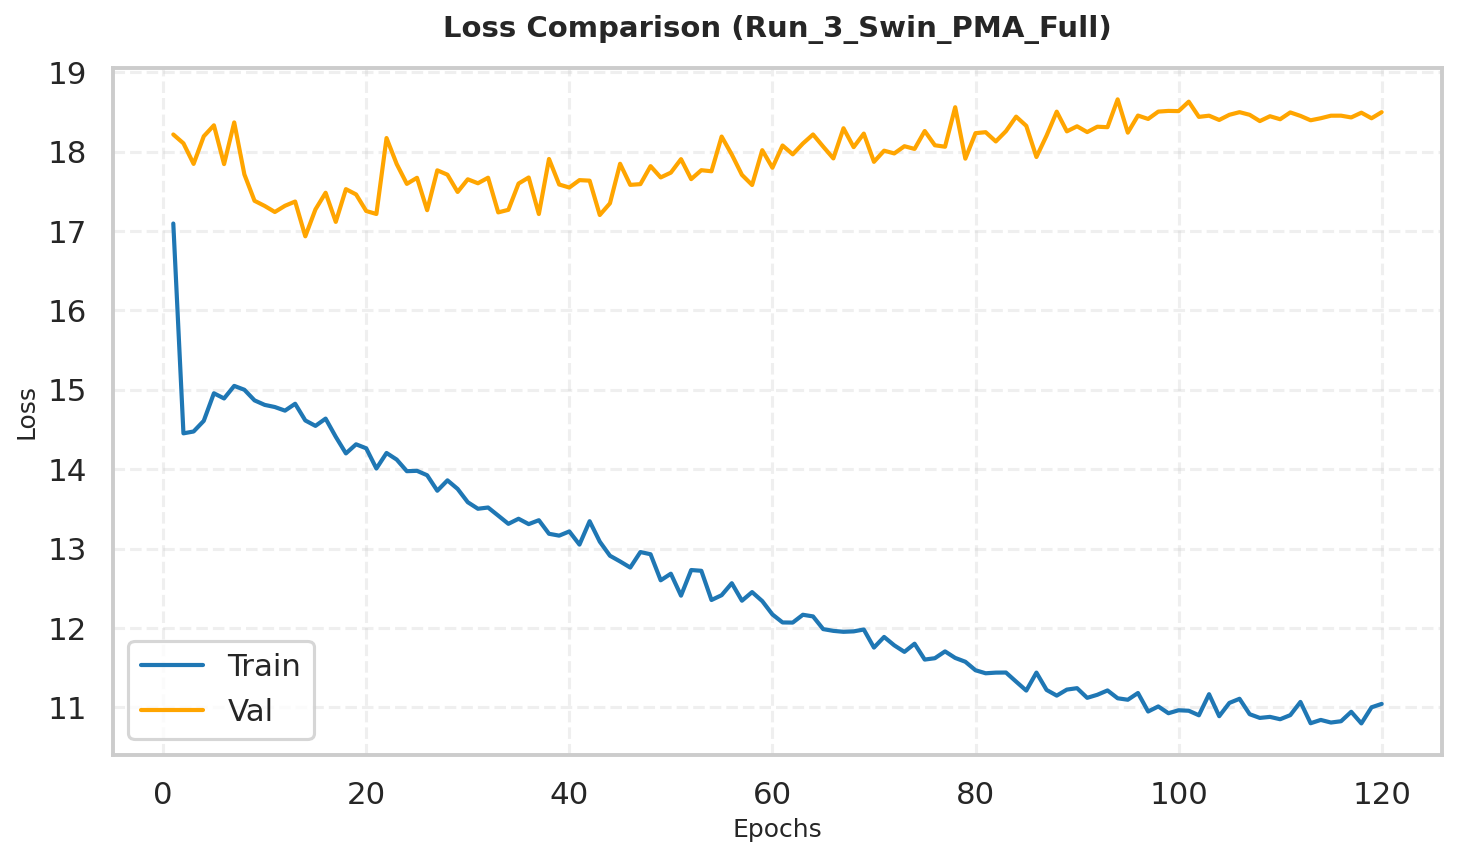

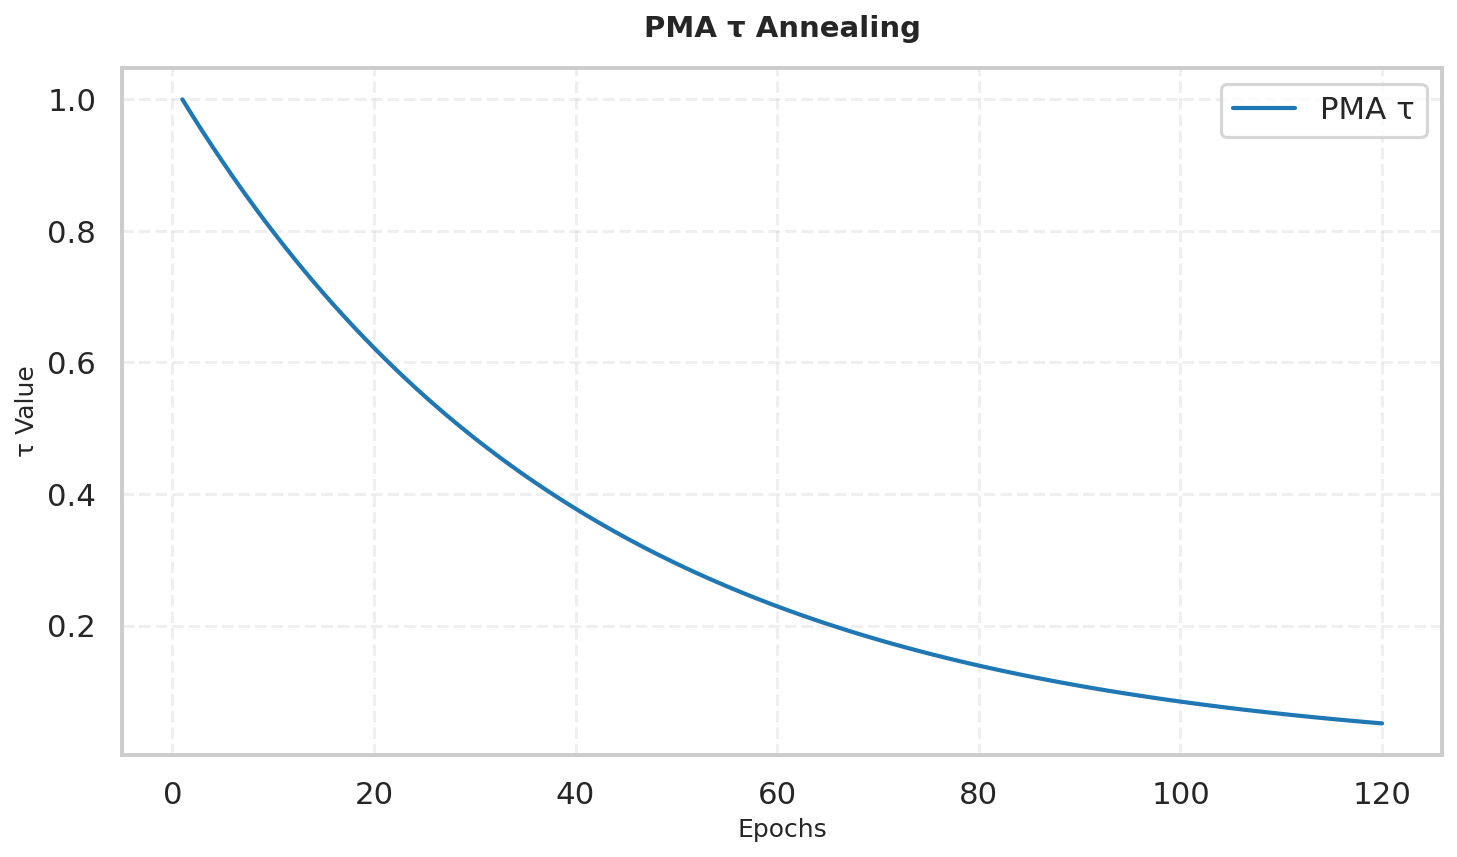

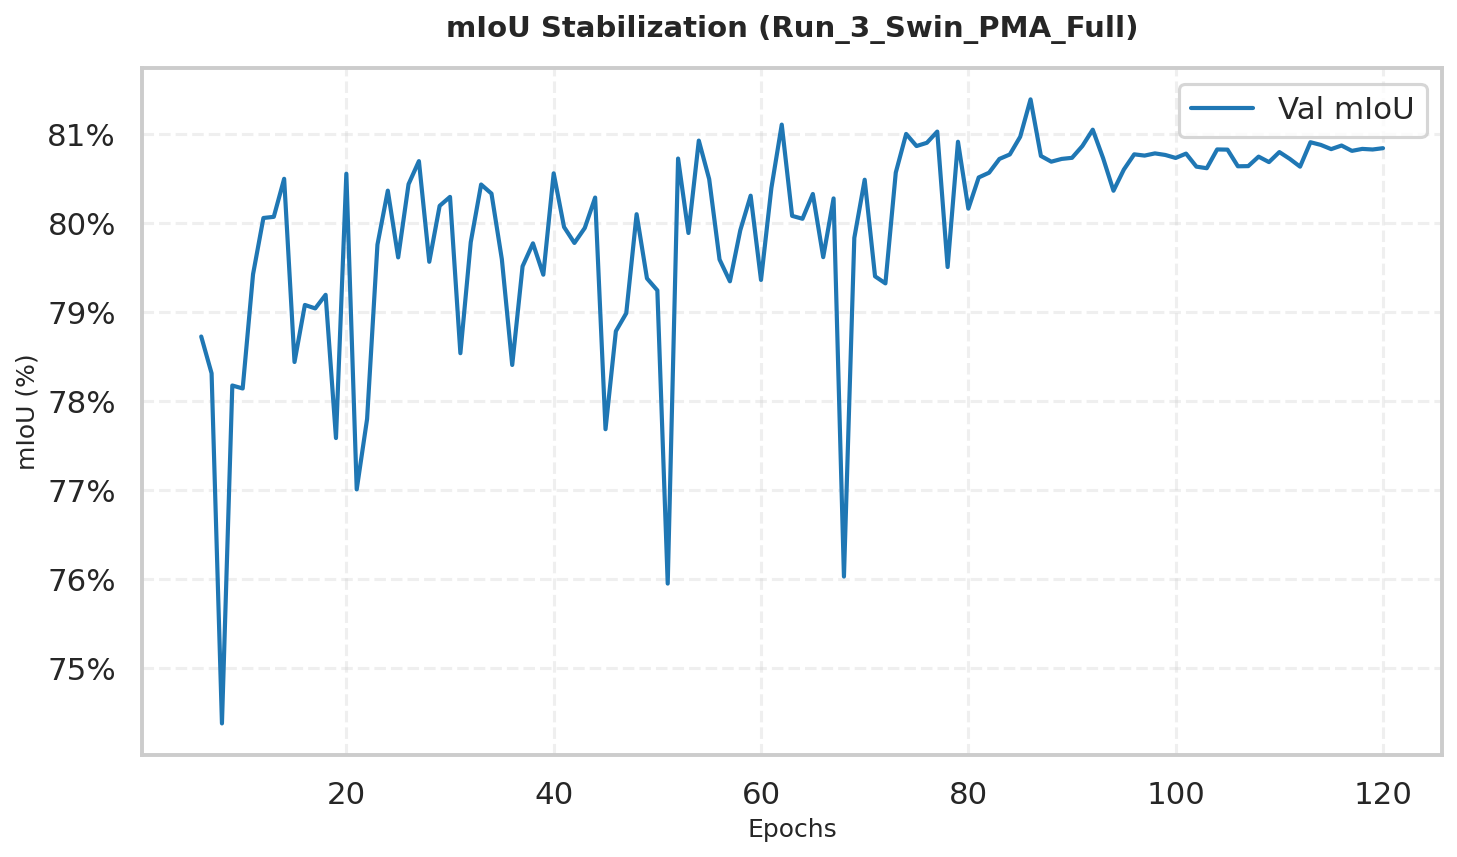

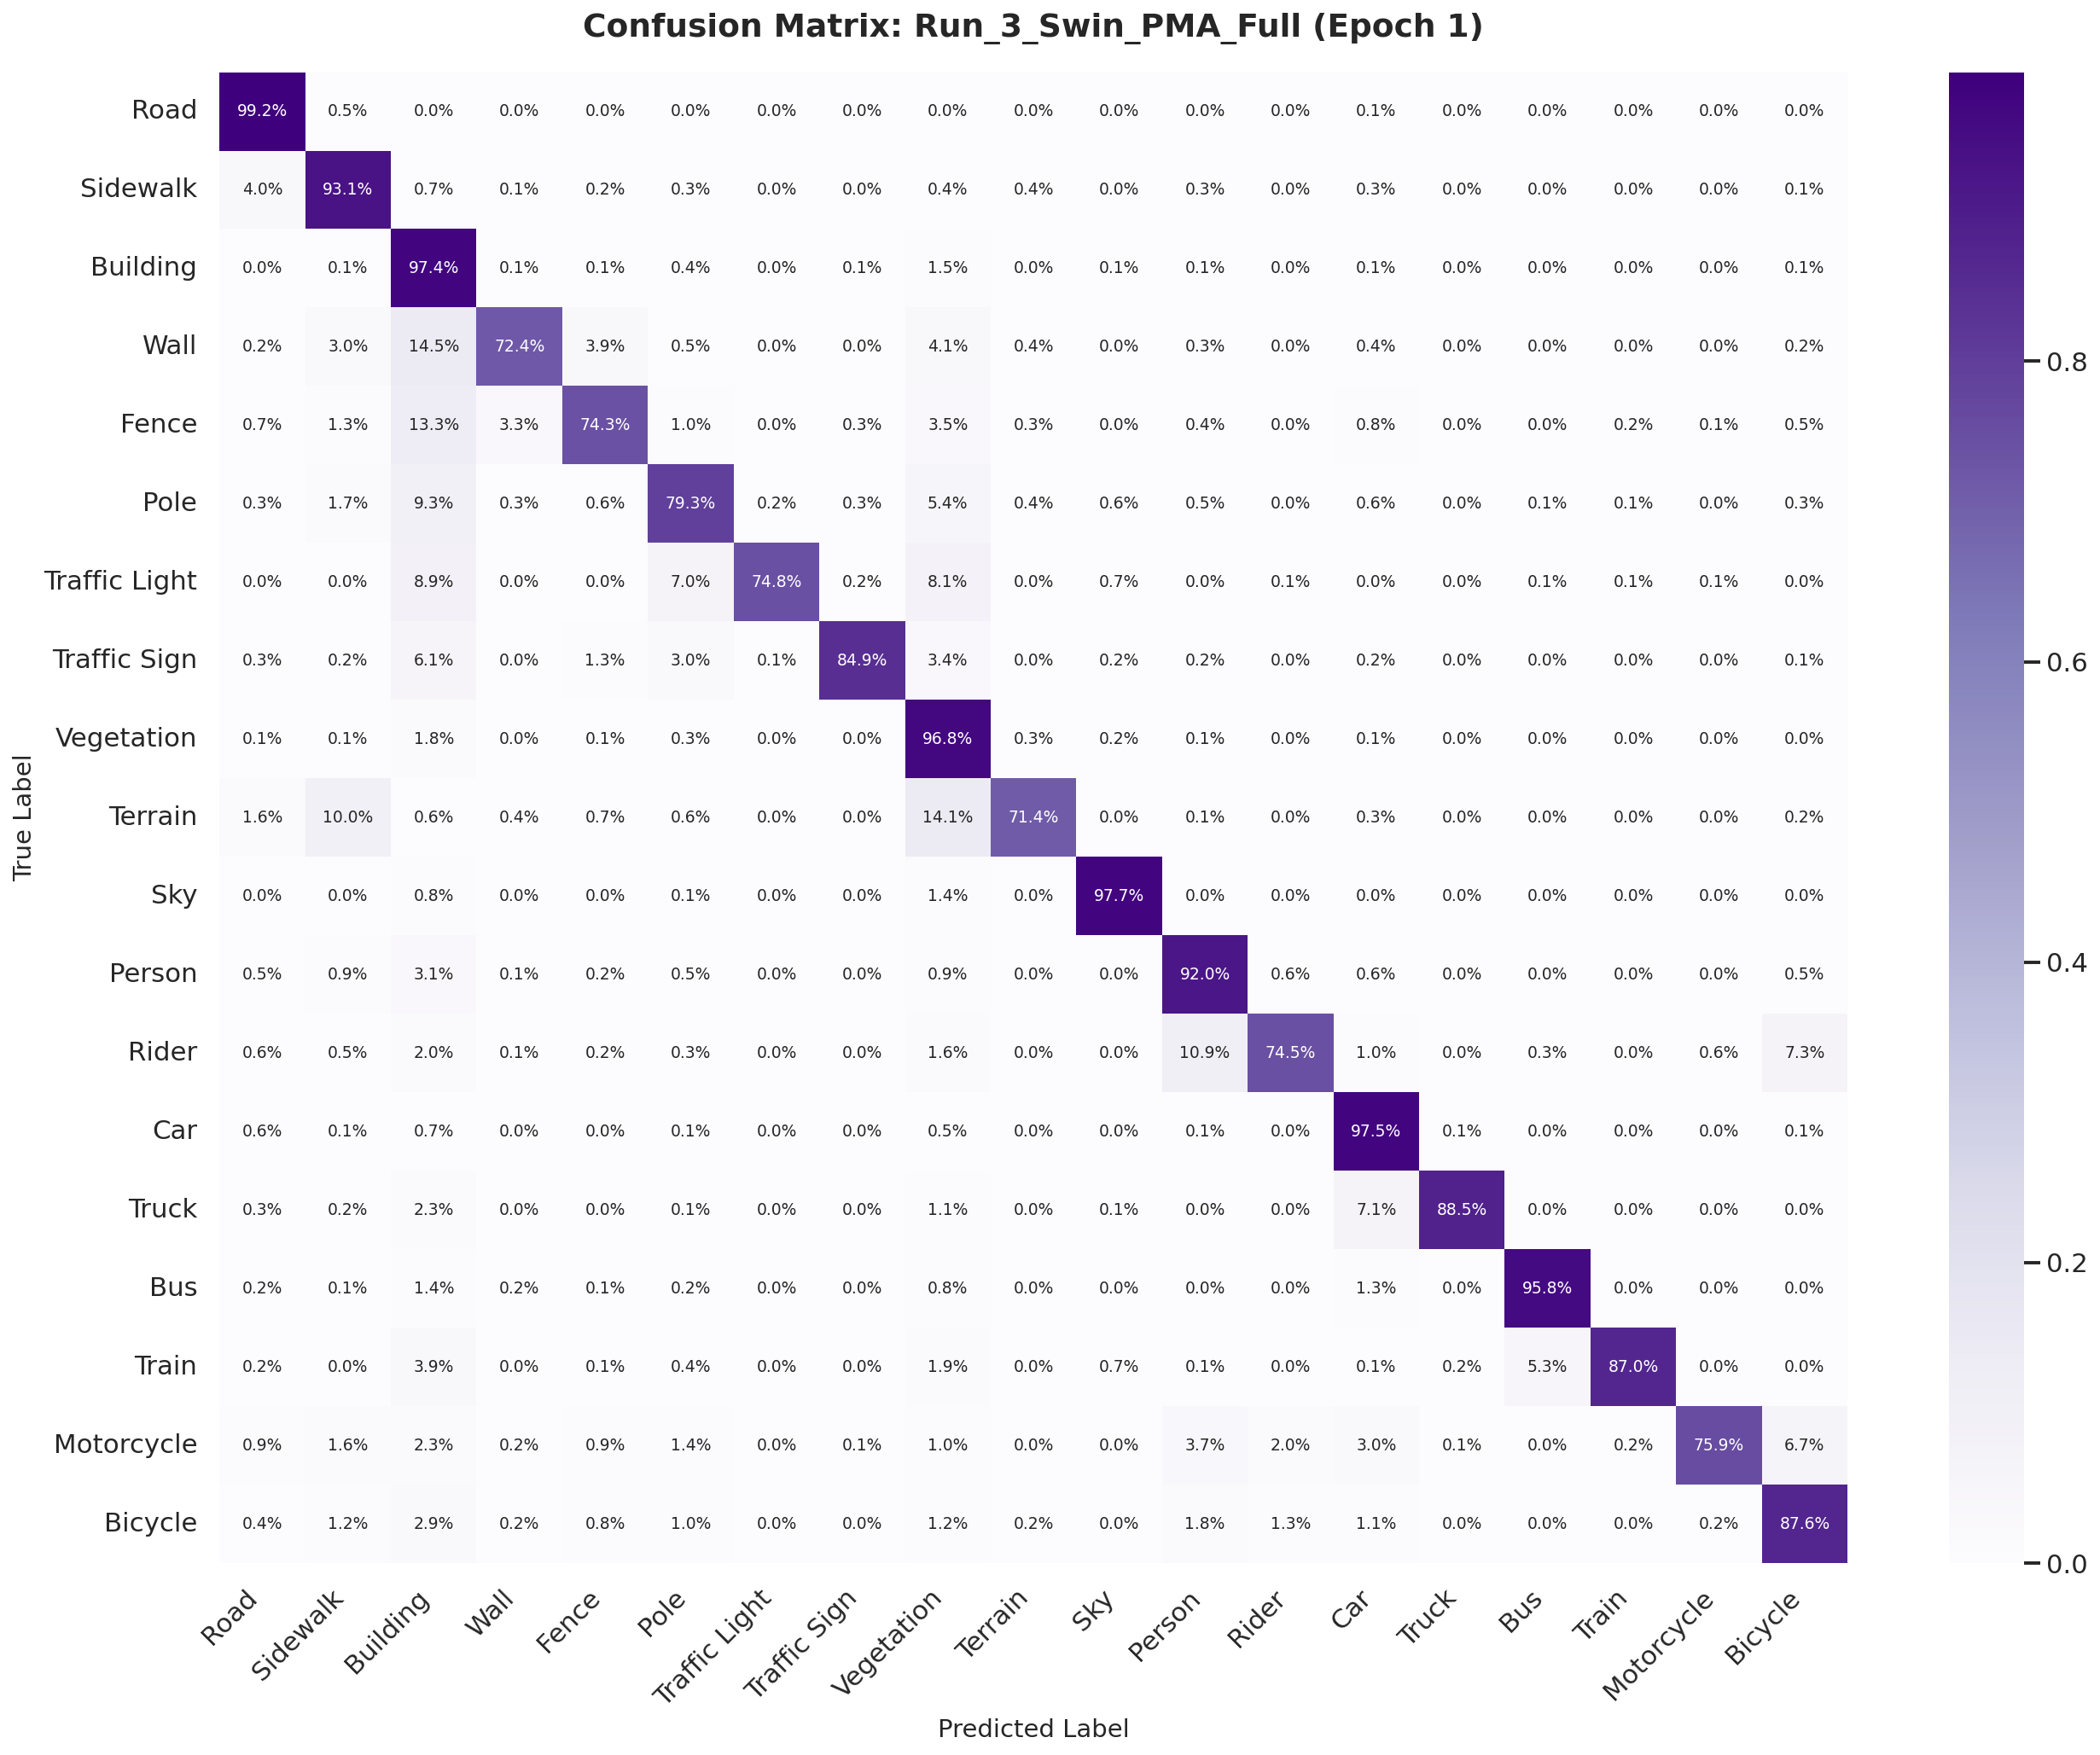


 ABLATION TRACKER: Run_3_Swin_PMA_Full 
Total Parameters:      68,725,406  (68.73 M)
Trainable Parameters:  68,725,406  (68.73 M)
------------------------------------------------------------
Best Validation mIoU:  81.90% (Epoch 1)
Final Epoch aAcc:      96.55%
Final Epoch mAcc:      86.33%
------------------------------------------------------------
CLASS NAME           | IoU (%)    | Accuracy (%)
------------------------------------------------------------
Road                 | 98.43      | 99.24     
Sidewalk             | 86.60      | 93.14     
Building             | 93.44      | 97.40     
Wall                 | 65.95      | 72.38     
Fence                | 65.69      | 74.29     
Pole                 | 68.33      | 79.29     
Traffic Light        | 70.71      | 74.79     
Traffic Sign         | 81.20      | 84.86     
Vegetation           | 92.84      | 96.84     
Terrain              | 64.17      | 71.42     
Sky                  | 95.18      | 97.66     
Person              

/home/ubuntu/miniconda3/envs/foggy/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...


Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping

[torch.onnx] Optimize the ONNX graph... ✅
[*] SUCCESS: ONNX Model exported to: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1/Results_Export/Run_3_Swin_PMA_Full/Run_3_Swin_PMA_Full.onnx


In [9]:
# ============================================================
# STEP 6: ABLATION STUDY EXPORT & COMPARATIVE TRACKING
# Target Architecture: Swin-Small + Mask2Former + PMA
# Optimized for: Master Ablation Ledgers, Isolated Run Folders,
# and ONNX Opset 18 Export
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Force Jupyter to display plots inline
%matplotlib inline

# ------------------------------------------------------------
# 1. ABLATION STUDY CONFIGURATION (Change this per run!)
# ------------------------------------------------------------
# Examples: "Run1_Baseline_ResNet", "Run2_Swin_No_PMA", "Run3_Swin_PMA_Full"
EXPERIMENT_NAME = "Run_3_Swin_PMA_Full" 

MANUAL_TOTAL_TIME_STR = "1 day, 10:52:57"

# ------------------------------------------------------------
# 2. SAFETY CHECKS & ISOLATED PATHS
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES",
    "CHECKPOINT_DIR", "best_record", "DEVICE"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

# Create a master export directory, and an ISOLATED directory for this specific run
MASTER_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("./Results_Export"))
RUN_SAVE_DIR = MASTER_SAVE_DIR / EXPERIMENT_NAME

MASTER_SAVE_DIR.mkdir(parents=True, exist_ok=True)
RUN_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"[*] Master Ablation Directory: {MASTER_SAVE_DIR.resolve()}")
print(f"[*] Current Run Directory:     {RUN_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# 3. RECOVERY METRICS HELPER 
# ------------------------------------------------------------
def compute_metrics_fallback(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    return {"mIoU": float(mIoU), "aAcc": float(aAcc), "mAcc": float(mAcc), "iou_per_class": iou_per_class, "acc_per_class": acc_per_class}

BEST_METRICS = globals().get("BEST_METRICS", None)
BEST_CONF_MATRIX = globals().get("BEST_CONF_MATRIX", None)

if BEST_CONF_MATRIX is None and "val_conf_matrix" in globals():
    print("[*] Notice: Live memory of best matrix lost during resume. Using Final Epoch's matrix.")
    BEST_CONF_MATRIX = globals().get("val_conf_matrix")
    BEST_METRICS = compute_metrics_fallback(BEST_CONF_MATRIX)

# ------------------------------------------------------------
# 4. BUILD MAIN DATAFRAME (Robust Key Finder)
# ------------------------------------------------------------
num_epochs = len(history.get("epoch", []))
if num_epochs == 0:
    # Fallback to checking length of train_loss if epoch key is missing
    num_epochs = len(history.get("train_loss", history.get("train_total_loss", [])))

def get_hist_col(keys):
    """Checks multiple possible dictionary keys to guarantee data is found"""
    if isinstance(keys, str): keys = [keys]
    for key in keys:
        col = history.get(key, [])
        if len(col) > 0:
            if len(col) == num_epochs: return col
            return col + [np.nan] * (num_epochs - len(col)) if len(col) < num_epochs else col[:num_epochs]
    return [np.nan] * num_epochs

df = pd.DataFrame({
    "Epoch": get_hist_col("epoch"),
    "Phase": get_hist_col("phase"),
    "Train_Loss": get_hist_col(["train_loss", "train_total_loss", "train_ce_loss"]),
    "Val_Loss": get_hist_col(["val_loss", "val_total_loss", "val_ce_loss"]),
    "Train_Boundary_Loss": get_hist_col("train_boundary_loss"),
    "PMA_Tau": get_hist_col(["pma_tau", "apma_tau"]),  
    "Train_aAcc": get_hist_col("train_aacc"),
    "Train_mIoU": get_hist_col("train_miou"),
    "Val_mIoU": get_hist_col("val_miou"),
    "Val_mAcc": get_hist_col("val_macc"),
    "Val_aAcc": get_hist_col("val_aacc"),
    "LR_Backbone": get_hist_col("backbone_lr"),
    "LR_Head": get_hist_col("head_lr"),
    "Epoch_Time_sec": get_hist_col("epoch_time_sec"),
})

# Handle the case where the epoch list was totally empty
if df["Epoch"].isna().all() and num_epochs > 0:
    df["Epoch"] = list(range(1, num_epochs + 1))

total_time_str = MANUAL_TOTAL_TIME_STR if MANUAL_TOTAL_TIME_STR else str(timedelta(seconds=int(df["Epoch_Time_sec"].sum(skipna=True))))
df["Total_Training_Session_Time"] = total_time_str

# ------------------------------------------------------------
# 5. PREPARE CLASS-WISE DATA
# ------------------------------------------------------------
class_wise_data = []
if BEST_METRICS is not None:
    for i, name in enumerate(CLASS_NAMES):
        class_wise_data.append({
            "Class Name": name,
            "IoU (%)": BEST_METRICS["iou_per_class"][i] * 100,
            "Accuracy (%)": BEST_METRICS["acc_per_class"][i] * 100
        })

# ------------------------------------------------------------
# 6. UPDATE MASTER ABLATION LEDGER
# ------------------------------------------------------------
def safe_pct(val):
    if pd.isna(val) or np.isnan(val): return 0.0
    return val if val > 1.0 else val * 100.0

final_v_acc = safe_pct(df["Val_aAcc"].iloc[-1])
final_mIoU = safe_pct(df["Val_mIoU"].iloc[-1])
final_mAcc = safe_pct(df["Val_mAcc"].iloc[-1])

if "val_miou" in history and len(history["val_miou"]) > 0:
    best_miou_raw = max(history["val_miou"])
    best_idx = history["val_miou"].index(best_miou_raw)
    best_epoch = history.get("epoch", list(range(1, num_epochs + 1)))[best_idx]
    best_miou = safe_pct(best_miou_raw)
else:
    best_epoch = best_record.get("best_epoch", -1)
    best_miou = safe_pct(best_record.get("best_miou", 0.0))

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create the summary dictionary for this specific run
run_summary = {
    "Experiment Name": EXPERIMENT_NAME,
    "Best Epoch": best_epoch,
    "Best Val mIoU (%)": round(best_miou, 2),
    "Final aAcc (%)": round(final_v_acc, 2),
    "Final mAcc (%)": round(final_mAcc, 2),
    "Total Params (M)": round(total_params / 1e6, 2),
    "Train Time": total_time_str
}

# Append to master ledger
ledger_path = MASTER_SAVE_DIR / "master_ablation_ledger.csv"
run_df = pd.DataFrame([run_summary])

if ledger_path.exists():
    master_df = pd.read_csv(ledger_path)
    # If the experiment name already exists, update it instead of duplicating
    if EXPERIMENT_NAME in master_df["Experiment Name"].values:
        master_df.set_index("Experiment Name", inplace=True)
        run_df.set_index("Experiment Name", inplace=True)
        master_df.update(run_df)
        master_df.reset_index(inplace=True)
    else:
        master_df = pd.concat([master_df, run_df], ignore_index=True)
    master_df.to_csv(ledger_path, index=False)
else:
    run_df.to_csv(ledger_path, index=False)

# Save detailed run files
run_df.to_csv(RUN_SAVE_DIR / "run_summary.csv", index=False)
try:
    with pd.ExcelWriter(RUN_SAVE_DIR / f"{EXPERIMENT_NAME}_Metrics.xlsx", engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='Epoch_Metrics', index=False)
        if class_wise_data:
            pd.DataFrame(class_wise_data).to_excel(writer, sheet_name='Class_Wise', index=False)
except ImportError: pass  

# ------------------------------------------------------------
# 7. STANDARD SEPARATE PLOTS (Saved to Run Folder)
# ------------------------------------------------------------
sns.set_style("whitegrid")

def save_and_show_plot(filename, title, ylabel, train_data, val_data=None, label1="Train", label2="Val", filter_warmup=False):
    plt.figure(figsize=(10, 6))
    start_idx = 5 if filter_warmup and len(train_data) > 5 else 0
    epochs_range = range(start_idx + 1, len(train_data) + 1)
    
    train_clean = np.array(train_data, dtype=float)[start_idx:]
    plt.plot(epochs_range, train_clean, label=label1, lw=2)
    
    if val_data is not None:
        val_clean = np.array(val_data, dtype=float)[start_idx:]
        if not np.isnan(val_clean).all():
            plt.plot(epochs_range, val_clean, label=label2, lw=2, color='orange')
            
    if "(%)" in ylabel: plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}%".format(int(x))))
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(RUN_SAVE_DIR / f"{filename}.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# Extract guaranteed data from robust columns
train_loss = df["Train_Loss"].tolist()
val_loss = df["Val_Loss"].tolist()
pma_tau = df["PMA_Tau"].tolist()

def ensure_pct(series):
    if series.isna().all(): return None
    return [x * 100 if (pd.notna(x) and x <= 1.0) else x for x in series.tolist()]

val_miou = ensure_pct(df["Val_mIoU"])
val_macc = ensure_pct(df["Val_mAcc"])

save_and_show_plot("loss_comparison", f"Loss Comparison ({EXPERIMENT_NAME})", "Loss", train_loss, val_loss)
if not df["PMA_Tau"].isna().all():
    save_and_show_plot("pma_tau_decay", "PMA \u03c4 Annealing", "\u03c4 Value", pma_tau, label1="PMA \u03c4")
if val_miou is not None:
    save_and_show_plot("miou_progress", f"mIoU Stabilization ({EXPERIMENT_NAME})", "mIoU (%)", val_miou, label1="Val mIoU", filter_warmup=True)

# ------------------------------------------------------------
# 8. PERCENTAGE-BASED CONFUSION MATRIX
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    plt.figure(figsize=(18, 14)) 
    cm_normalized = BEST_CONF_MATRIX.astype('float') / (BEST_CONF_MATRIX.sum(axis=1)[:, np.newaxis] + 1e-10)
    sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Purples', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot_kws={"size": 9}) 
    
    plt.title(f"Confusion Matrix: {EXPERIMENT_NAME} (Epoch {best_epoch})", fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(RUN_SAVE_DIR / "confusion_matrix.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# ------------------------------------------------------------
# 9. FINAL SUMMARY (Restored Class-wise Output)
# ------------------------------------------------------------
print(f"\n" + "="*60)
print(f" ABLATION TRACKER: {EXPERIMENT_NAME} ")
print("="*60)
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print("-" * 60)
print(f"Best Validation mIoU:  {best_miou:.2f}% (Epoch {best_epoch})")
print(f"Final Epoch aAcc:      {final_v_acc:.2f}%")
print(f"Final Epoch mAcc:      {final_mAcc:.2f}%")
print("-" * 60)
print(f"{'CLASS NAME':<20} | {'IoU (%)':<10} | {'Accuracy (%)':<10}")
print("-" * 60)

if class_wise_data:
    for item in class_wise_data:
        print(f"{item['Class Name']:<20} | {item['IoU (%)']:<10.2f} | {item['Accuracy (%)']:<10.2f}")
else:
    print("[!] No class-wise data available in memory to print.")

print("-" * 60)
print(f"[*] Ledger Updated: {ledger_path.resolve()}")
print(f"[*] Artifacts Saved: {RUN_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# 10. ONNX MODEL EXPORT (Opset 18)
# ------------------------------------------------------------
print("\n--- Exporting Model to ONNX ---")
try:
    model.eval()
    dummy_input = torch.randn(1, 3, 512, 1024, device=DEVICE)
    onnx_path = RUN_SAVE_DIR / f"{EXPERIMENT_NAME}.onnx"
    
    with torch.no_grad():
        torch.onnx.export(
            model, dummy_input, str(onnx_path),
            export_params=True, opset_version=18, 
            do_constant_folding=True, input_names=['input_image'], output_names=['mask_predictions']
        )
    print(f"[*] SUCCESS: ONNX Model exported to: {onnx_path.resolve()}")
except Exception as e:
    print(f"[!] Info: ONNX export skipped: {e}")

[*] Presentation graph will be safely exported to:
/home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1/Results_Export/Run_3_Swin_PMA_Full
[*] Success! Graph preserved at:
/home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1/Results_Export/Run_3_Swin_PMA_Full/presentation_metrics_Run_3_Swin_PMA_Full.png


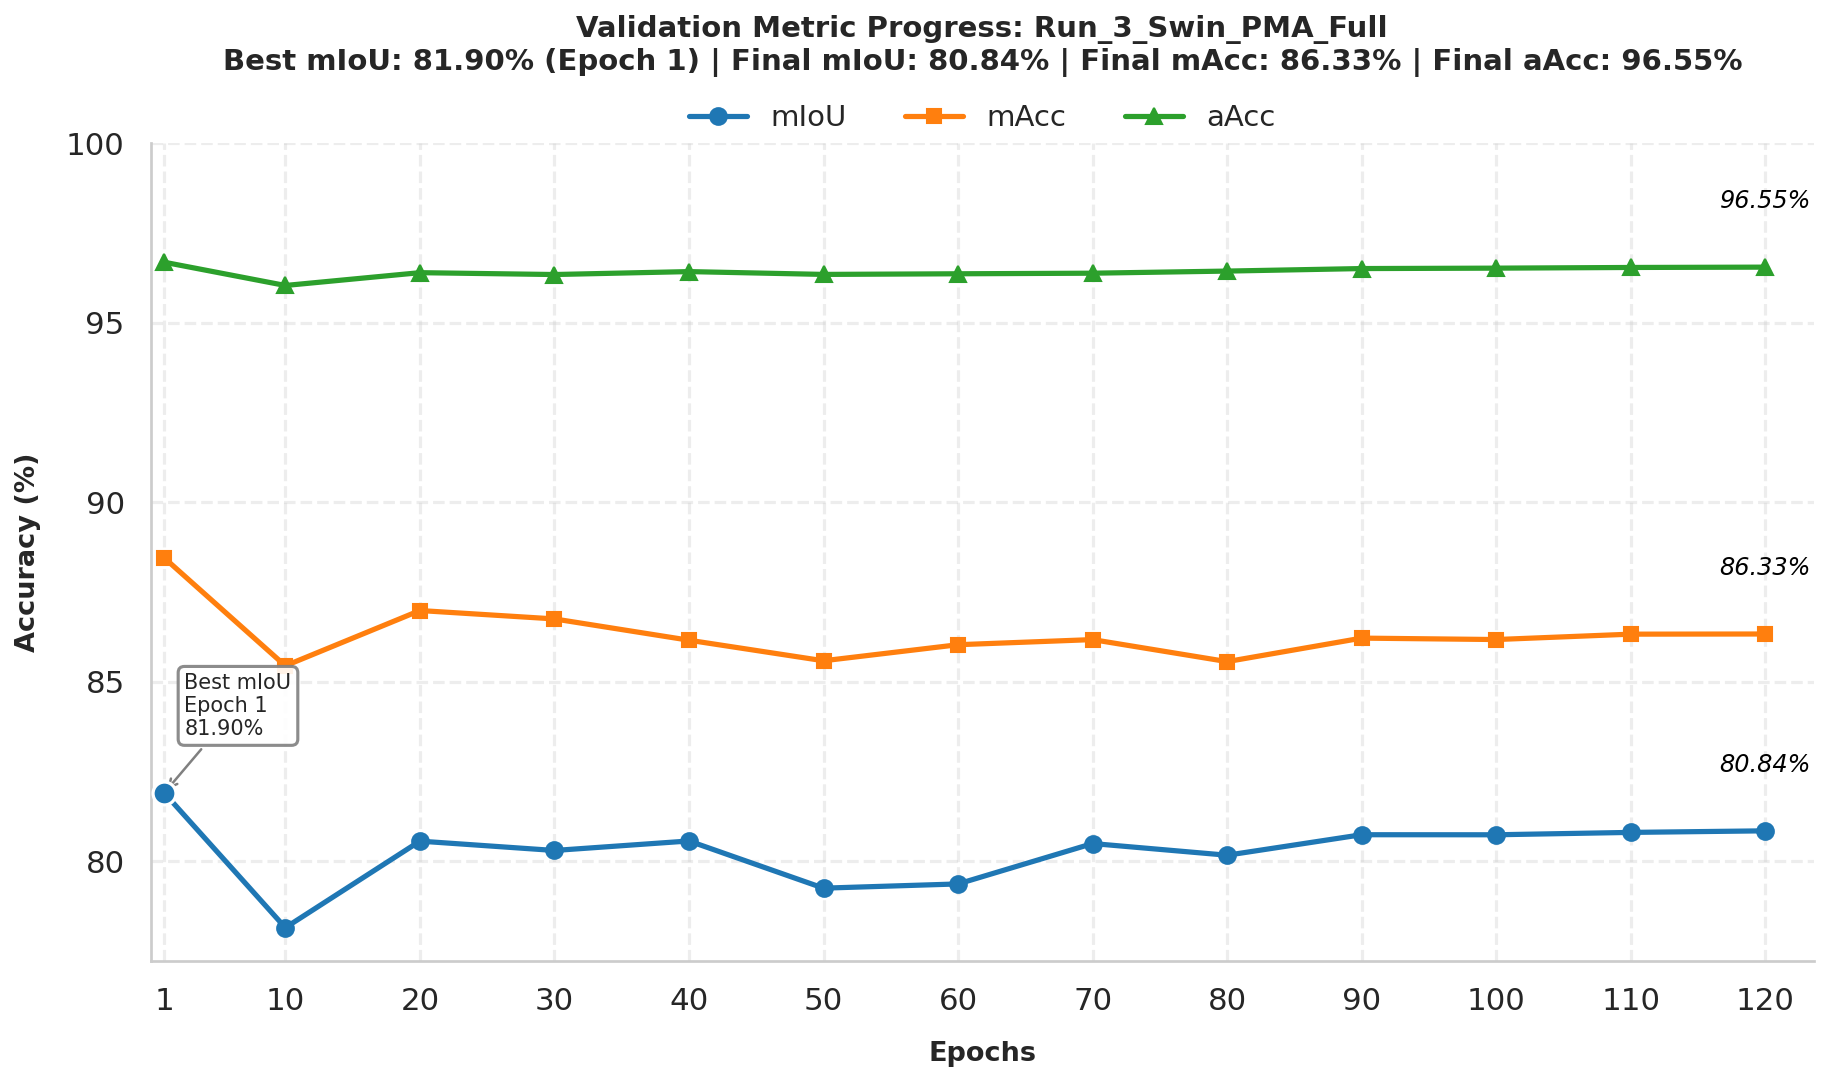

In [10]:
# ============================================================
# STEP 7: PRESENTATION-READY MULTI-METRIC PROGRESS GRAPH
# Target Architecture: Swin-Small + Mask2Former + PMA
# Optimized for: Ablation Study Isolation, Specific Epoch Intervals,
# and Strict Percentage Scaling for Publication
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# SAFETY CHECKS & ABLATION PATH INHERITANCE
# ------------------------------------------------------------
required_globals = ["history"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

if "val_miou" not in history or len(history["val_miou"]) == 0:
    raise ValueError("history['val_miou'] is empty. Run training before Step 7.")

# Securely inherit the specific run directory and experiment name from Step 6
EXPERIMENT_NAME = globals().get("EXPERIMENT_NAME", "Default_Ablation_Run")
MASTER_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("./Results_Export"))
RUN_SAVE_DIR = globals().get("RUN_SAVE_DIR", MASTER_SAVE_DIR / EXPERIMENT_NAME)

# Ensure the directory exists just in case
RUN_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"[*] Presentation graph will be safely exported to:\n{RUN_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# PREPARE EPOCHS & DATA
# ------------------------------------------------------------
# Fallback generator if the explicit "epoch" list is missing from older checkpoints
num_epochs = len(history["val_miou"])
all_epochs = history.get("epoch", list(range(1, num_epochs + 1)))

# Safe percentage converter
def safe_pct(val):
    return val * 100.0 if val <= 1.0 else float(val)

# Bulletproof Best Epoch Extraction
best_miou_raw = max(history["val_miou"])
best_idx = history["val_miou"].index(best_miou_raw)
best_miou = safe_pct(best_miou_raw)
best_miou_epoch = all_epochs[best_idx]

# Filter epochs to reduce visual clutter: Epoch 1, every 10th epoch, best epoch, final epoch
filtered_epochs_set = set([e for e in all_epochs if e == 1 or e % 10 == 0] + [all_epochs[-1], best_miou_epoch])
filtered_epochs = sorted(list(filtered_epochs_set))

indices = [all_epochs.index(e) for e in filtered_epochs]

# Extract and convert to percentages for cleaner presentation
miou_scores = [safe_pct(history["val_miou"][i]) for i in indices]
macc_scores = [safe_pct(history["val_macc"][i]) for i in indices]
aacc_scores = [safe_pct(history["val_aacc"][i]) for i in indices]

final_miou = safe_pct(history["val_miou"][-1])
final_macc = safe_pct(history["val_macc"][-1])
final_aacc = safe_pct(history["val_aacc"][-1])
final_x = all_epochs[-1]

# ------------------------------------------------------------
# PLOT SETUP 
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.5, 7.5)) 

color_miou = '#1f77b4'  # Blue
color_macc = '#ff7f0e'  # Orange
color_aacc = '#2ca02c'  # Green

ax.plot(filtered_epochs, miou_scores, marker='o', linewidth=2.5, markersize=8, label='mIoU', color=color_miou)
ax.plot(filtered_epochs, macc_scores, marker='s', linewidth=2.5, markersize=7, label='mAcc', color=color_macc)
ax.plot(filtered_epochs, aacc_scores, marker='^', linewidth=2.5, markersize=8, label='aAcc', color=color_aacc)

# ------------------------------------------------------------
# AXIS LABELS
# ------------------------------------------------------------
ax.set_xlabel('Epochs', fontsize=13, fontweight='bold', labelpad=12)
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold', labelpad=12)
ax.set_xticks(filtered_epochs)

# ------------------------------------------------------------
# BEST mIoU ANNOTATION 
# ------------------------------------------------------------
ax.scatter(best_miou_epoch, best_miou, s=120, zorder=5, color=color_miou, edgecolors='white', linewidth=1.5)

if best_miou_epoch <= (max(filtered_epochs) * 0.6):
    best_text_x = best_miou_epoch + 1.5
    best_ha = "left"
else:
    best_text_x = best_miou_epoch - 1.5
    best_ha = "right"

ax.annotate(
    f'Best mIoU\nEpoch {best_miou_epoch}\n{best_miou:.2f}%',
    xy=(best_miou_epoch, best_miou),
    xytext=(best_text_x, best_miou + 1.5),
    fontsize=10, ha=best_ha, va='bottom',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2)
)

# ------------------------------------------------------------
# END-OF-LINE FINAL VALUE ANNOTATIONS (Floating above markers)
# ------------------------------------------------------------
offset_y = 1.5

ax.text(final_x, final_miou + offset_y, f'{final_miou:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')
ax.text(final_x, final_macc + offset_y, f'{final_macc:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')
ax.text(final_x, final_aacc + offset_y, f'{final_aacc:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')

ax.set_xlim(left=0, right=max(all_epochs) + (max(all_epochs) * 0.03))
ax.set_ylim(top=100) 

# ------------------------------------------------------------
# STYLING & LEGEND
# ------------------------------------------------------------
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, frameon=False, fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.3)
ax.spines['left'].set_linewidth(1.3)

ax.grid(True, linestyle='--', alpha=0.35)

# Dynamically injecting the specific EXPERIMENT_NAME into the title
title_main = f"Validation Metric Progress: {EXPERIMENT_NAME}"
title_sub = f"Best mIoU: {best_miou:.2f}% (Epoch {best_miou_epoch}) | Final mIoU: {final_miou:.2f}% | Final mAcc: {final_macc:.2f}% | Final aAcc: {final_aacc:.2f}%"

ax.set_title(
    title_main + "\n" + title_sub,
    fontsize=14, fontweight='bold', pad=35
)

plt.tight_layout()

# ------------------------------------------------------------
# ISOLATED RUN SAVE
# ------------------------------------------------------------
# Includes the specific experiment name in the PNG file for safe copying
combined_graph_path = RUN_SAVE_DIR / f"presentation_metrics_{EXPERIMENT_NAME}.png"
plt.savefig(combined_graph_path, dpi=600, bbox_inches='tight')
print(f"[*] Success! Graph preserved at:\n{combined_graph_path.resolve()}")

plt.show()
plt.close()

[*] Success! Learning Rate curve saved to:
/home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_NO_Freezing_AB1/Results_Export/Run_3_Swin_PMA_Full/learning_rate_schedule.png


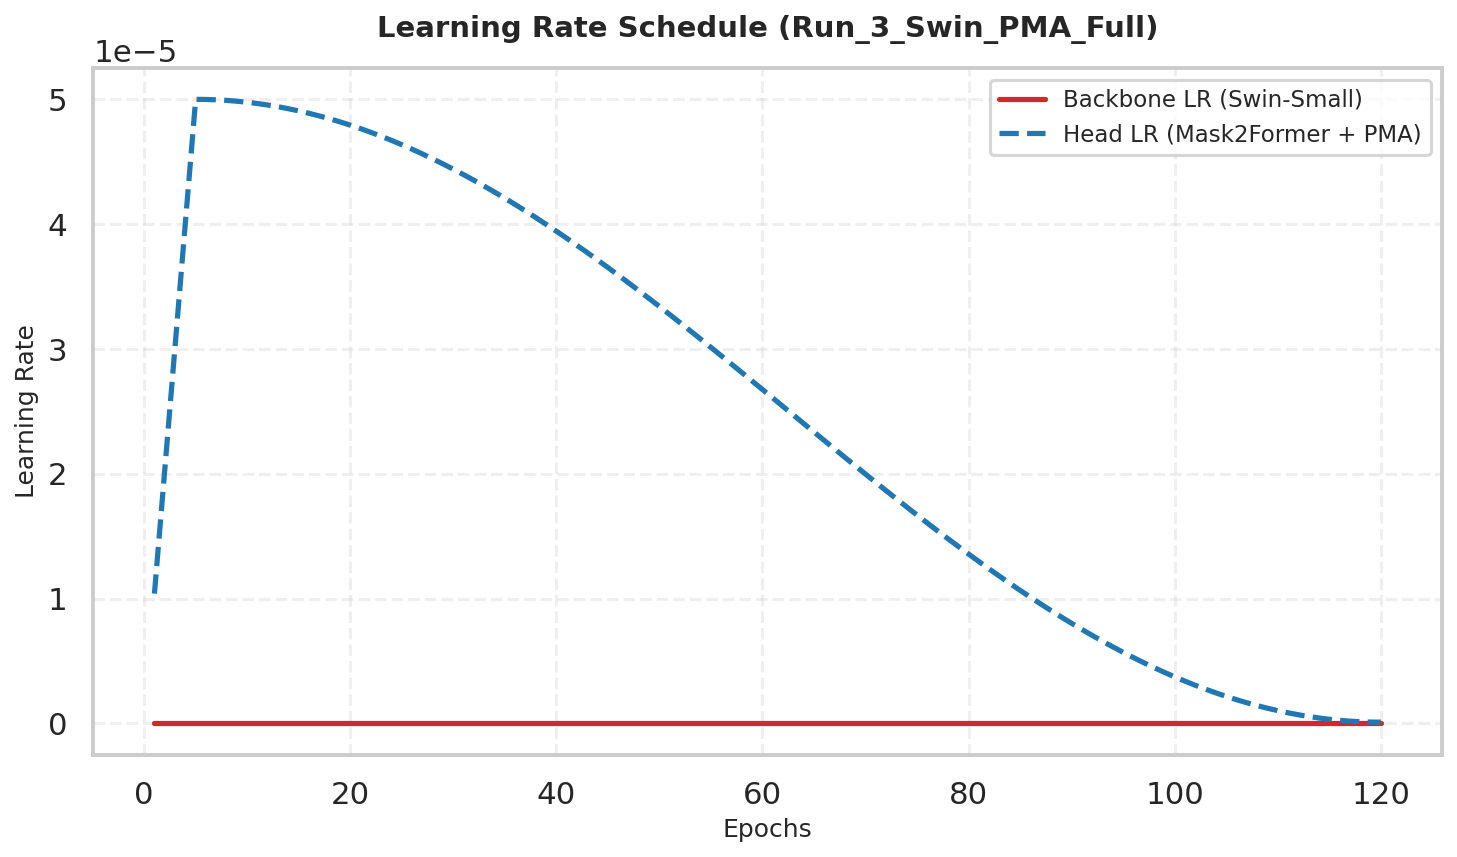

In [11]:
# ============================================================
# LEARNING RATE SCHEDULE VISUALIZATION
# Tracks Backbone and Head LRs across Epochs
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ensure styling matches the other ablation graphs
sns.set_style("whitegrid")

# Extract Epochs and Learning Rates from the existing dataframe
epochs_range = df["Epoch"].dropna().tolist()
lr_backbone = df["LR_Backbone"].dropna().tolist()
lr_head = df["LR_Head"].dropna().tolist()

if len(lr_backbone) > 0 and len(lr_head) > 0:
    plt.figure(figsize=(10, 6))
    
    # Plot Backbone LR (Solid line) and Head LR (Dashed line)
    plt.plot(epochs_range, lr_backbone, label="Backbone LR (Swin-Small)", color="#d62728", linewidth=2.5, linestyle="-")
    plt.plot(epochs_range, lr_head, label="Head LR (Mask2Former + PMA)", color="#1f77b4", linewidth=2.5, linestyle="--")
    
    plt.title(f"Learning Rate Schedule ({EXPERIMENT_NAME})", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Learning Rate", fontsize=12)
    
    # Format Y-axis to use scientific notation (e.g., 1e-4) since LRs are very small
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # Save directly to the isolated ablation run folder
    lr_plot_path = RUN_SAVE_DIR / f"learning_rate_schedule.png"
    plt.savefig(lr_plot_path, dpi=600, bbox_inches='tight')
    
    print(f"[*] Success! Learning Rate curve saved to:\n{lr_plot_path.resolve()}")
    plt.show()
    plt.close()
else:
    print("[!] Error: No Learning Rate data found in the training history DataFrame.")